# 07 — Criação do Dataset & Motor de Instruções (BIA)

## Introdução

### Objetivo
Construir um pipeline **fim a fim** para gerar e validar um **dataset de instruções** (mensagens rotuladas por intenção) e um **motor de resposta** híbrido (regras + ML/BERTimbau) alinhado ao `fluxos.yaml`. O notebook:
- Consolida artefatos (classificador prévio, label encoder, thresholds, `label_map.yaml`, `fluxos.yaml`);
- Normaliza rótulos para o **conjunto canônico** de intents (do `fluxos.yaml`);
- Extrai **entidades-chave** (CEP, id de pedido, tamanho, categoria) e aplica **regras heurísticas**;
- Combina predição por **ML** com **máquina de estados** + templates;
- Avalia contra rótulos do NB03, **identifica confusões**, exporta erros e **gera dataset balanceado** para re/treino;
- Fine-tuna e publica um **BERTimbau** compatível (labels/id2label), e integra ao `respond()`.

### Perguntas-guia (o que o leitor leva desta etapa)
1. Quais são as **intents canônicas** e como garantir que rótulos divergentes colapsem para elas?  
2. Como **threshold** e **gap top-2** impactam “outros” vs. assertividade?  
3. Onde estão as **confusões mais frequentes** (verdadeiro → previsto) e o que priorizar de curadoria?  
4. O motor (estados/transições/guards) está **coerente** com os templates e com as **entidades** extraídas?  
5. O pipeline é **idempotente e portátil** (paths, fallbacks, parquet/CSV, patches de engine/service/actions)?  
6. O dataset final atende aos **requisitos de treino** (split estratificado, balanceamento, mapeamento estável de labels)?

### Etapas (visão resumida)
1) Setup de ambiente e **paths** (repo, `code/resources`, `notebook07_{inputs,outputs}`)  
2) Carga de **artefatos de modelo** (classifier/LE/embedding) + **thresholds** com fallback  
3) Leitura do `fluxos.yaml` e do `label_map.yaml` → **normalização/collapse** para intents canônicas  
4) **Extração de entidades** + **regras** (NLU heurístico) e **predição ML** com `THRESH`/`GAP_TOP2`  
5) **State machine** (guards, actions, templates) e render de resposta  
6) **Classificação em lote** de CSV novo (INBOX) e **avaliação** com NB03 (report + matriz de confusão)  
7) **Sweep** de thresholds; **debug** e checagem de consistência modelo ↔ YAML  
8) **Exports**: misclassifications, dataset balanceado p/ re/treino; **catálogo** normalizado (parquet/CSV)  
9) **Patches** idempotentes (engine/service/actions/templates)  
10) **Fine-tuning BERTimbau** (Datasets/Transformers), **salvar** artefatos, **publicar** no Hub e **trocar** `predict_ml` → BERT

### Saídas (principais)
- `notebook07_outputs/`:  
  - `misclassified_for_retrain.csv`, `balanced_nb03_for_training.csv`, `bert_{train,val}_preview.csv`  
  - `catalogo_normalizado.parquet` (ou `.csv`) + `catalogo_pointer.txt`  
  - `modelos/bertimbau_intents/` (modelo + tokenizer + `labels.json`)  
  - `modelos/thresholds.json` atualizado  
- `resources/fluxos.yaml` atualizado (template `sugestoes_result`, ações padronizadas)

In [390]:
# CÉLULA 1 — Imports e utilitários básicos
# Objetivo: garantir execução robusta (local/Colab), prints de ambiente e funções auxiliares simples.

from pathlib import Path
from datetime import datetime
import platform
import sys, os, re, json
import numpy as np
import pandas as pd

def first_existing(paths):
    """Retorna o primeiro Path existente dentro de uma lista (ou None). Útil para fallbacks."""
    for p in paths:
        p = Path(p)
        if p.exists():
            return p
    return None

def find_repo_root():
    """
    Sobe diretórios até achar uma raiz de projeto contendo /code e /code/resources.
    Mantém notebook portátil (não depende do cwd exato).
    """
    here = Path.cwd()
    for p in [here, *here.parents]:
        if (p / "code").exists() and (p / "code" / "resources").exists():
            return p
    return here  # fallback: usa cwd mesmo sem estrutura padrão

def norm_text(s: str) -> str:
    """Normaliza espaços (colapsa múltiplos em um), remove bordas; não mexe em acentuação/caixa."""
    return re.sub(r"\s+", " ", s).strip()

print(">> Rodando localmente.")
print("Base:", Path.cwd())
print("SO:", platform.platform())
print("Início:", datetime.now().strftime("%Y-%m-%dT%H:%M:%S"))


>> Rodando localmente.
Base: c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks
SO: Windows-11-10.0.26100-SP0
Início: 2025-09-23T21:43:35


In [391]:
# CÉLULA 2 — Caminhos fixos (limpos)
# Convenções de pastas do repositório + "inbox/outbox" dedicados deste notebook (07).
# Mantém isolamento entre notebooks (facilita debug e limpeza).

REPO_ROOT   = find_repo_root()
CODE_DIR    = REPO_ROOT / "code"
RESOURCES_DIR = CODE_DIR / "resources"
NOTEBOOKS_DIR = CODE_DIR / "notebooks"
MODELOS_DIR = NOTEBOOKS_DIR / "modelos"
INBOX       = NOTEBOOKS_DIR / "notebook07_inputs"   # entrada específica deste NB
OUTBOX      = NOTEBOOKS_DIR / "notebook07_outputs"  # saídas específicas deste NB

INBOX.mkdir(parents=True, exist_ok=True)
OUTBOX.mkdir(parents=True, exist_ok=True)

print("REPO_ROOT:", REPO_ROOT)
print("CODE_DIR :", CODE_DIR)
print("RESOURCES_DIR:", RESOURCES_DIR)
print("MODELOS_DIR:", MODELOS_DIR)
print("INBOX:", INBOX)
print("OUTBOX:", OUTBOX)


REPO_ROOT: c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04
CODE_DIR : c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code
RESOURCES_DIR: c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\resources
MODELOS_DIR: c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\modelos
INBOX: c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\notebook07_inputs
OUTBOX: c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\notebook07_outputs


In [392]:
# CÉLULA 3 — Versões das libs
# Diagnóstico rápido de ambiente (evita surpresas em execução em outra máquina/Colab).

import importlib
def v(mod):
    try:
        return importlib.import_module(mod).__version__
    except Exception:
        return "n/a"

print("VERSÕES:")
print(" - yaml                 :", v("yaml"))
print(" - pandas               :", v("pandas"))
print(" - numpy                :", v("numpy"))
print(" - sklearn              :", v("sklearn"))
print(" - sentence_transformers:", v("sentence_transformers"))


VERSÕES:
 - yaml                 : 6.0.2
 - pandas               : 2.3.2
 - numpy                : 2.3.3
 - sklearn              : 1.7.2
 - sentence_transformers: 5.1.0


In [393]:
# CÉLULA 4 — Carrega artefatos do modelo (corrigida)
# Carrega o classificador calibrado gerado nos notebooks anteriores (outputs/models/intents_calibrated)
# e usa meta.json para reconstruir o LabelEncoder quando necessário.

import joblib, json
from pathlib import Path
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import LabelEncoder

def _list_dir(p: Path):
    try:
        return sorted([x.name for x in p.iterdir()])
    except Exception:
        return []

def _models_candidates():
    base = NOTEBOOKS_DIR
    outs = base / "outputs" / "models"
    return [
        MODELOS_DIR,                           # code/notebooks/modelos
        outs / "intents_calibrated",           # code/notebooks/outputs/models/intents_calibrated  ← ALVO
        outs,                                  # code/notebooks/outputs/models
        NOTEBOOKS_DIR / "notebook03_outputs" / "modelos",
        NOTEBOOKS_DIR / "notebook04_outputs" / "modelos",
        NOTEBOOKS_DIR / "notebook05_outputs" / "modelos",
        REPO_ROOT / "models",
        REPO_ROOT / "artifacts",
        Path("/mnt/data"),
    ]

print("🔎 Procurando artefatos do classificador em:")
for d in _models_candidates():
    status = "existe" if d.exists() else "não existe"
    content = _list_dir(d) if d.exists() else []
    print(f" - {d} ({status})")
    if content: print("   conteúdo:", content)

# alvo preferencial (clf.joblib + meta.json)
CLF_DIR = None
for d in _models_candidates():
    if (d / "clf.joblib").exists() and (d / "meta.json").exists():
        CLF_DIR = d
        break

CLF = None
LE  = None

if CLF_DIR:
    CLF = joblib.load(CLF_DIR / "clf.joblib")
    meta = json.loads((CLF_DIR / "meta.json").read_text(encoding="utf-8"))
    classes = meta.get("classes") or meta.get("labels") or meta.get("id2label")
    if isinstance(classes, dict):  # id2label
        # ordena por id numérico se veio como dict
        classes = [v for k,v in sorted(classes.items(), key=lambda kv: int(kv[0]))]
    if classes:
        LE = LabelEncoder()
        LE.fit(list(map(str, classes)))
        print(f"✓ Classificador carregado de: {CLF_DIR/'clf.joblib'}")
        print(f"✓ LabelEncoder OK (classes: {len(LE.classes_)} )")
    else:
        print("⚠️  meta.json encontrado, mas sem lista de classes — seguirei sem LE (fallback regras).")
else:
    print("⚠️  Não encontrei clf.joblib + meta.json nas pastas candidatas.")
    print("   → O pipeline usa regras primeiro; o ML só entra quando disponível.")

# Nome do embedder (compatível com o classificador)
EMB_MODEL_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
print("✓ Embedder configurado:", EMB_MODEL_NAME)
EMB = SentenceTransformer(EMB_MODEL_NAME)
print("✓ Embedder carregado.")

# Thresholds
THRESH, GAP_TOP2 = 0.50, 0.10
thr_path = first_existing([MODELOS_DIR / "thresholds.json", REPO_ROOT / "thresholds.json"])
if thr_path and thr_path.exists():
    try:
        meta_thr = json.loads(thr_path.read_text(encoding="utf-8"))
        THRESH   = float(meta_thr.get("threshold", THRESH))
        GAP_TOP2 = float(meta_thr.get("gap_top2", GAP_TOP2))
    except Exception:
        pass
print(f"✓ Thresholds carregados de {thr_path or 'default'} | THRESH={THRESH:.2f} GAP_TOP2={GAP_TOP2:.2f}")


🔎 Procurando artefatos do classificador em:
 - c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\modelos (existe)
   conteúdo: ['artefatos_v1', 'bertimbau_intents', 'llm_consultora', 'reports', 'thresholds.json']
 - c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\outputs\models\intents_calibrated (existe)
   conteúdo: ['clf.joblib', 'meta.json']
 - c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\outputs\models (existe)
   conteúdo: ['catalog_index', 'intents_calibrated']
 - c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\notebook03_outputs\modelos (não existe)
 - c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\notebook04_outputs\modelos (não existe)
 - c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\notebook05_outputs\modelos (não existe)
 - c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\models (não existe)
 - c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\artifacts (não ex

c:\Users\win\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\win\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator _SigmoidCalibration from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\win\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle esti

✓ Embedder carregado.
✓ Thresholds carregados de c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\modelos\thresholds.json | THRESH=0.50 GAP_TOP2=0.10


In [394]:
# CÉLULA 5 — Carrega fluxos.yaml
# Fonte de verdade para intents canônicas, estados e templates.
# Falhas aqui indicam problemas estruturais do projeto (não siga adiante se assert falhar).

import yaml

YAML_FILE = RESOURCES_DIR / "fluxos.yaml"
assert YAML_FILE.exists(), f"fluxos.yaml não encontrado em {YAML_FILE}"
FLOW = yaml.safe_load(YAML_FILE.read_text(encoding="utf-8"))

for k in ["intents", "states", "templates"]:
    assert k in FLOW, f"YAML sem chave obrigatória: {k}"

INTENTS_YAML = set(FLOW["intents"])
STATES = FLOW["states"]
TEMPLATES = FLOW["templates"]
FALLBACKS = FLOW.get("fallbacks", {}) or {}

print("✓ YAML localizado em:", YAML_FILE)
print("Intents no YAML:", len(INTENTS_YAML))
print("Estados (amostra):", ", ".join(list(STATES.keys())[:8]), "…")
print("Templates (amostra):", ", ".join(list(TEMPLATES.keys())[:8]), "…")


✓ YAML localizado em: c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\resources\fluxos.yaml
Intents no YAML: 20
Estados (amostra): START, CAPTURA_INTENCAO, RECOMENDAR, BUSCA_PRODUTO, INFO_ESTOQUE, INFO_FRETE, INFO_PAGAMENTO, STATUS_PEDIDO …
Templates (amostra): boas_vindas, agradecimento, encerrar, pedir_cep, pedir_pedido_id, outros, handoff, fora_horario …


In [395]:
# CÉLULA 6 — Carrega label_map.yaml (normalização + collapse) com canônicos do fluxos.yaml
# Ponto crítico: mantém coerência entre rótulos históricos e o conjunto canônico (YAML).
# 'unknown_to' define para onde vai o que não bate (tipicamente 'outros').

import yaml, unicodedata, re
from pathlib import Path

LABELMAP_CANDIDATES = [
    RESOURCES_DIR / "label_map.yaml",
    CODE_DIR / "resources" / "label_map.yaml",
]

def first_existing(paths):
    """Versão global da função para reuso em múltiplas células."""
    for p in paths:
        p = Path(p)
        if p.exists():
            return p
    return None

def load_labelmap(paths):
    """Carrega label_map.yaml (se existir) e retorna (dict, path)."""
    lm_path = first_existing(paths)
    if lm_path and lm_path.exists():
        lm = yaml.safe_load(lm_path.read_text(encoding="utf-8")) or {}
        print("✓ label_map carregado de:", lm_path)
        return lm, lm_path
    print("Aviso: label_map.yaml não encontrado nas opções:\n- " + "\n- ".join(map(str, paths)))
    return {}, None

LABELMAP, LABELMAP_FILE = load_labelmap(LABELMAP_CANDIDATES)

# Intents canônicos = os do fluxos.yaml (fonte única)
CANON_INTENTS = set(FLOW.get("intents", []))
UNKNOWN_TO    = LABELMAP.get("unknown_to", "outros")

# Aliases de colunas e collapse_to
COL_ALIASES = LABELMAP.get("column_aliases", {
    "texto":  ["texto", "mensagem", "utterance", "frase", "message"],
    "intent": ["intent", "intencao", "intenção", "label", "rotulo", "rótulo",
               "classe", "target", "y", "label_regra"],
})
COLLAPSE   = LABELMAP.get("collapse_to", {}) or {}
DROP_LABS  = set(LABELMAP.get("drop_labels", []))

# Normalização (casefold/acentos/substituições)
NMZ      = LABELMAP.get("normalize", {}) or {}
CASEFOLD = bool(NMZ.get("casefold", True))
STRIP_ACC= bool(NMZ.get("strip_accents", True))
REPLACE  = NMZ.get("replace", {}) or {}

def _strip_acc(s: str) -> str:
    if not isinstance(s, str): return s
    return "".join(c for c in unicodedata.normalize("NFD", s) if unicodedata.category(c) != "Mn")

def _norm_key(s: str) -> str:
    """Normaliza -> minúsculas/sem acento/substituições, troca espaços por '_' (chave estável)."""
    if not isinstance(s, str):
        s = "" if s is None else str(s)
    x = s
    if STRIP_ACC: x = _strip_acc(x)
    if CASEFOLD:  x = x.casefold()
    for a, b in REPLACE.items():
        x = x.replace(a, b)
    x = x.strip()
    x = re.sub(r"\s+", "_", x)
    return x

def _build_reverse_collapse(coll: dict) -> dict:
    """Mapeia variantes → canônico (chave normalizada)."""
    rev = {}
    for canon, variants in (coll or {}).items():
        canon_k = _norm_key(canon)
        for v in (variants or []):
            vk = _norm_key(v)
            if vk and vk != canon_k:
                rev[vk] = canon_k
    return rev

REVMAP_COLLAPSE = _build_reverse_collapse(COLLAPSE)

def canon_label(raw) -> str:
    """
    Normaliza + collapse e garante pertencimento ao conjunto canônico (fluxos.yaml).
    Caso contrário, envia para UNKNOWN_TO (padrão: 'outros').
    """
    k = _norm_key("" if raw is None else str(raw))
    if k in REVMAP_COLLAPSE:
        k = REVMAP_COLLAPSE[k]
    if k not in CANON_INTENTS:
        k = UNKNOWN_TO
    return k

# Logs de conferência (úteis para auditar mapeamentos)
print("→ Aliases de colunas:", COL_ALIASES)
if COLLAPSE:
    total_vars = sum(len(v or []) for v in COLLAPSE.values())
    print(f"→ collapse_to: {len(COLLAPSE)} canônicos; {total_vars} variantes mapeadas.")
if DROP_LABS:
    print("→ Rótulos a descartar:", sorted(DROP_LABS))
print("→ unknown_to:", UNKNOWN_TO)
print("→ intents CANÔNICAS (fluxos.yaml):", len(CANON_INTENTS))


✓ label_map carregado de: c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\resources\label_map.yaml
→ Aliases de colunas: {'texto': ['texto', 'mensagem', 'utterance', 'frase', 'message'], 'intent': ['intent', 'intencao', 'intenção', 'label', 'rotulo', 'rótulo', 'classe', 'target', 'y', 'label_regra']}
→ collapse_to: 4 canônicos; 4 variantes mapeadas.
→ unknown_to: outros
→ intents CANÔNICAS (fluxos.yaml): 20


# 🔎 Checkpoint de Normalização & Mapeamento de Rótulos

Este bloco garante que **rótulos do dataset** e **intents do `fluxos.yaml`** falem a mesma língua antes de treinar/avaliar.

## O que cada chave faz (resumo prático)
- **`column_aliases`**: traduz nomes de colunas do CSV (`texto`, `intent` etc.). Se der “coluna não encontrada”, ajuste aqui.
- **`normalize`**:
  - `casefold`: deixa tudo minúsculo com regras de idioma (bom pra pt-BR).
  - `strip_accents`: remove acentos (útil pra juntar “intenção” e “intencao”).
  - `replace`: correções específicas (ex.: `" / "` → `"_"`).
- **`collapse_to`**: mapeia *apelidos* → *canônico* (ex.: `duvida_pagamento` ← `formas_de_pagar`, `cartão`…).
- **`unknown_to`**: rótulos fora do conjunto canônico vão para **este balde** (padrão: `outros`).
- **`drop_labels`**: rótulos que devem ser **descartados** do dataset (ruído, testes, etc.).

## Checklist (tem que bater!)
1. **Intents canônicas** (do `fluxos.yaml`) ≥ 1 e fazem sentido para o seu domínio.
2. **`collapse_to` cobre sinônimos** frequentes (veja `clusters_to_labelmap.yaml` do NB08 depois).
3. **`unknown_to` aparece pouco** (se crescer, você está perdendo sinônimos no `collapse_to`).
4. **`drop_labels`** remove apenas o que *realmente* é lixo.
5. Logs desta etapa mostram algo como:
   - “→ intents CANÔNICAS: *N*”
   - “→ collapse_to: *X* canônicos; *Y* variantes mapeadas.”

> Dica: se o `unknown_to` estourar, **não ajuste o modelo** primeiro — **enriqueça o `collapse_to`** e re-rodar.


In [396]:
# CÉLULA 7 — Extratores de entidades (corrigida)
# Evita falso-positivo de pedido.id ao ver CEP; só extrai pedido se houver menção explícita.
import re

CATEGORIAS = {"vestido", "blusa", "calca", "saia", "macaquinho", "casaco", "acessorio", "outro"}
TAMANHOS = {"pp","p","m","g","gg","xg","xxg","36","38","40","42","44","46"}

# CEP padrão BR (aceita com/sem hífen)
CEP_RE = re.compile(r"\b(\d{5})-?(\d{3})\b")

# Pedido: alfanumérico 5–10, MAS somente se houver a palavra 'pedido' próxima
# - janela de até 30 chars depois de 'pedido' (ex.: "meu pedido é 3F9A1B")
PEDIDO_CTX_RE = re.compile(
    r"\bpedido\w*\b[^\w]{0,10}([A-Z0-9]{5,10})",
    flags=re.I
)

# Tamanho (tam: X) e fallback para tokens isolados do conjunto TAMANHOS
TAM_RE = re.compile(r"\btam(?:anho)?[: ]?([pxmg]{1,2}|\d{2})\b", flags=re.I)

def extract_entities(texto: str):
    """
    Extrai entidades comuns do domínio Curadobia. Retorna dict.
    Regras:
      - geo.cep: 00000-000 (ou sem hífen)
      - pedido.id: só quando houver 'pedido' explícito no texto
      - tamanho_ref: 'tam:' ou tokens PP,P,M,G.../36,38...
      - categoria: match literal de dicionário CATEGORIAS
    """
    ents = {}
    if not isinstance(texto, str) or not texto:
        return ents

    t = texto.strip()

    # CEP
    if m := CEP_RE.search(t):
        ents["geo.cep"] = f"{m.group(1)}-{m.group(2)}"

    # Pedido (somente com contexto 'pedido')
    if m := PEDIDO_CTX_RE.search(t):
        pid = m.group(1).upper()
        # segurança extra: não confunde com CEP (já extraído como geo.cep)
        if not re.fullmatch(r"\d{5}", pid):
            ents["pedido.id"] = pid

    # Tamanho
    if m := TAM_RE.search(t):
        ents["tamanho_ref"] = m.group(1).lower()
    else:
        for tg in TAMANHOS:
            if re.search(rf"\b{re.escape(tg)}\b", t, flags=re.I):
                ents["tamanho_ref"] = tg
                break

    # Categoria
    for c in CATEGORIAS:
        if re.search(rf"\b{re.escape(c)}\b", t, flags=re.I):
            ents["categoria"] = c
            break

    return ents


In [397]:
# CÉLULA 8 — Regras heurísticas (ampliadas)

RE_PAT = lambda xs: re.compile(r"|".join([rf"\b{re.escape(x)}\b" for x in xs]), re.I)

RULES = [
    ("saudacao", RE_PAT(["oi", "olá", "ola", "bom dia", "boa tarde", "boa noite"])),
    ("despedida", RE_PAT(["tchau", "até mais", "até logo", "falou"])),
    ("agradecimento", RE_PAT(["obrigado", "obrigada", "valeu", "show", "perfeito"])),
    ("formas_pagamento", RE_PAT(["formas de pagamento", "forma de pagamento", "pagamento", "parcel", "pix", "boleto", "cartao", "cartão"])),
    ("frete_prazo", RE_PAT(["frete", "prazo de entrega", "prazo", "entrega", "envio", "cep"])),
    ("disponibilidade", RE_PAT(["estoque", "disponibilidade", "tem no tamanho", "tem tamanho", "tem estoque"])),
    ("status_pedido", RE_PAT(["status do pedido", "rastreio", "rastrear", "acompanhar", "tracking"])),
    ("falar_com_humano", RE_PAT(["humano", "pessoa", "atendente", "atendimento humano"])),
    ("troca_devolucao", RE_PAT(["troca", "devolução", "devolucao"])),
    ("onde_comprar", RE_PAT(["onde comprar", "como comprar", "link do produto", "link"])),
    ("materiais_cuidados", RE_PAT(["tecido", "material", "composição", "composicao", "cuidados", "lavar", "passar"])),
    ("tamanho_modelagem", RE_PAT(["tamanho", "veste", "medidas", "busto", "cintura", "quadril", "altura", "numeração", "numeracao"])),
    ("styling_sugestao_look", RE_PAT(["look", "combinar", "ocasião", "ocasiao", "usar com", "dica de look"])),
    ("cupom_primeira", RE_PAT(["cupom", "desconto", "primeira compra"])),
    # 👇 novo: “não consigo finalizar compra”, “erro no checkout”, etc.
    ("erros_plataforma", RE_PAT([
        "não consigo finalizar a compra", "nao consigo finalizar a compra",
        "erro no checkout", "erro no pagamento", "bug no site", "problema no site",
        "falha no carrinho", "carrinho não atualiza", "carrinho nao atualiza",
        "checkout travou", "checkout travando", "checkout não funciona", "checkout nao funciona"
    ])),
]

def rule_based_intent(texto: str, ents: dict):
    t = texto.lower()
    if "geo.cep" in ents and re.search(r"\b(frete|entrega|prazo)\b", t):
        return ("frete_prazo", "rule:frete_cep")
    if "pedido.id" in ents and re.search(r"\b(status|rastre)\w*", t):
        return ("status_pedido", "rule:status_pedido")
    if "tamanho_ref" in ents or "categoria" in ents:
        if re.search(r"\b(tem|estoque|disponibilidade)\b", t):
            return ("disponibilidade", "rule:estoque_cat")

    for intent, pat in RULES:
        if pat.search(t):
            return (intent, f"rule:{intent}")
    return (None, None)


In [398]:
# CÉLULA 9 — Predição por ML (com proteção quando CLF/LE faltarem)
def predict_ml(texto: str):
    """
    Usa EMB + CLF calibrado. Se CLF/LE não estiverem disponíveis, retorna 'outros' com conf baixa.
    """
    if CLF is None or LE is None:
        return "outros", 0.0, 0.0
    z = EMB.encode([texto], normalize_embeddings=False)
    proba = CLF.predict_proba(z)[0]
    idx_top = np.argsort(proba)[::-1]
    top1 = idx_top[0]
    top2 = idx_top[1] if len(idx_top) > 1 else idx_top[0]
    conf = float(proba[top1])
    gap  = float(proba[top1] - proba[top2]) if len(idx_top) > 1 else conf
    intent_raw = str(LE.inverse_transform([top1])[0])
    return intent_raw, conf, gap


In [399]:
# CÉLULA 10 — Motor de estados + resposta (corrigida)

def eval_guard(guard: str, entities: dict) -> bool:
    if not guard:
        return True
    guard = guard.strip()
    m = re.match(r"^(!)?has\(([^)]+)\)$", guard)
    if not m:
        return True
    neg, key = m.groups()
    has = key in entities
    return (not has) if neg else has

def render_template(name: str, ctx: dict):
    tpl = TEMPLATES.get(name)
    if not tpl:
        return None
    out = tpl
    for k, v in ctx.items():
        out = out.replace("{{"+k+"}}", str(v))
    return out

def next_state(curr_state: str, intent: str, entities: dict):
    state_def = STATES.get(curr_state, {})
    trans = state_def.get("transitions", [])
    for tr in trans:
        if tr.get("intent") in (intent, "any"):
            if eval_guard(tr.get("guard"), entities):
                return tr.get("next"), tr.get("action")
    fb = FALLBACKS.get("on_unrecognized_intent", {})
    return fb.get("next", "CAPTURA_INTENCAO"), None

def respond(texto: str, curr_state: str="START"):
    texto = norm_text(texto)
    ents  = extract_entities(texto)

    # 1) Regras primeiro
    rule_int, heur = rule_based_intent(texto, ents)

    # 2) ML (pode vir com rótulos não canônicos)
    intent_raw, conf, gap = predict_ml(texto)

    # 3) Decisão + canonização:
    if rule_int:
        intent_use = rule_int
    else:
        intent_ml = choose_intent(intent_raw, conf, gap)
        intent_use = canon_label(intent_ml)  # <- garante canônico (ou 'outros')

    # 4) Transição + action
    ns, act = next_state(curr_state, intent_use, ents)

    # 5) Template de entrada (se houver)
    entry = STATES.get(ns, {}).get("entry", {})
    resp = None
    if entry:
        tpl_name = entry.get("template")
        ctx = {
            "tamanho": ents.get("tamanho_ref", ""),
            "caimento": "padrão",
            "peca": ents.get("categoria", ""),
            "ocasiao": ""
        }
        resp = render_template(tpl_name, ctx) if tpl_name else None

    return {
        "state_in": curr_state,
        "texto": texto,
        "intent": intent_use,
        "intent_raw": intent_raw,
        "conf": round(conf, 4),
        "gap_top2": round(gap, 4),
        "heuristica": heur,
        "entities": ents,
        "action": act,
        "state_out": ns,
        "resposta_sugerida": resp or TEMPLATES.get("boas_vindas"),
    }


In [400]:
# CÉLULA 11 — Smoke tests
# Verifica encadeamento básico (regras + ML + transição + template). Não é avaliação formal.

tests = [
    "oi, tudo bem?",
    "quais as formas de pagamento?",
    "qual o prazo de entrega pro CEP 01234-567?",
    "tem vestido M em estoque?",
    "não consigo finalizar a compra",
    "meu pedido é 3F9A1B, qual o status?",
]
for t in tests:
    r = respond(t, "START")
    print(">", t)
    print(r)


> oi, tudo bem?
{'state_in': 'START', 'texto': 'oi, tudo bem?', 'intent': 'saudacao', 'intent_raw': 'saudacao', 'conf': 0.7618, 'gap_top2': 0.5634, 'heuristica': 'rule:saudacao', 'entities': {}, 'action': None, 'state_out': 'CAPTURA_INTENCAO', 'resposta_sugerida': 'Oi! Eu sou a BIBI da Curadobia. Posso calcular frete, formas de pagamento, tamanho, estoque e mais. Em que te ajudo? ✨'}
> quais as formas de pagamento?
{'state_in': 'START', 'texto': 'quais as formas de pagamento?', 'intent': 'formas_pagamento', 'intent_raw': 'formas_pagamento', 'conf': 0.6204, 'gap_top2': 0.367, 'heuristica': 'rule:formas_pagamento', 'entities': {}, 'action': None, 'state_out': 'CAPTURA_INTENCAO', 'resposta_sugerida': 'Oi! Eu sou a BIBI da Curadobia. Posso calcular frete, formas de pagamento, tamanho, estoque e mais. Em que te ajudo? ✨'}
> qual o prazo de entrega pro CEP 01234-567?
{'state_in': 'START', 'texto': 'qual o prazo de entrega pro CEP 01234-567?', 'intent': 'frete_prazo', 'intent_raw': 'frete_pra

In [401]:
# CÉLULA 12 — Classificar CSV novo OU lista inline
# Se não houver CSV, usa msgs_inline (lista logo abaixo).

infile = INBOX / "mensagens_novas.csv"

# edite esta lista para testar sem CSV:
msgs_inline = [
    "oi bibi",
    "quero saber formas de pagamento",
    "qual o prazo de entrega pro CEP 04567-890?",
    "tem vestido M em estoque?",
    "meu pedido é 3F9A1B, qual o status?",
]

rows = []
if infile.exists():
    df = pd.read_csv(infile)
    assert "texto" in df.columns, "CSV precisa de coluna 'texto'."
    textos = df["texto"].astype(str).tolist()
    print(f"✓ Lendo {len(textos)} mensagens de", infile)
else:
    textos = [str(x) for x in msgs_inline]
    print("⚠️  CSV não encontrado; usando msgs_inline (", len(textos), "msgs ).")

for txt in textos:
    rows.append(respond(txt))

out = pd.DataFrame(rows)
outfile = OUTBOX / "mensagens_classificadas.csv"
out.to_csv(outfile, index=False, encoding="utf-8")
print("✓ Classificado. Arquivo:", outfile)
display(out.head(10))


⚠️  CSV não encontrado; usando msgs_inline ( 5 msgs ).
✓ Classificado. Arquivo: c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\notebook07_outputs\mensagens_classificadas.csv


,state_in,texto,intent,intent_raw,conf,gap_top2,heuristica,entities,action,state_out,resposta_sugerida
0,START,oi bibi,saudacao,saudacao,0.5089,0.1742,rule:saudacao,{},None,CAPTURA_INTENCAO,Oi! Eu sou a BIBI da Curadobia. Posso calcular...
1,START,quero saber formas de pagamento,formas_pagamento,formas_pagamento,0.7894,0.6423,rule:formas_pagamento,{},None,CAPTURA_INTENCAO,Oi! Eu sou a BIBI da Curadobia. Posso calcular...
2,START,qual o prazo de entrega pro CEP 04567-890?,frete_prazo,frete_prazo,0.7557,0.6725,rule:frete_cep,{'geo.cep': '04567-890'},None,CAPTURA_INTENCAO,Oi! Eu sou a BIBI da Curadobia. Posso calcular...
3,START,tem vestido M em estoque?,disponibilidade,saudacao,0.5833,0.1949,rule:estoque_cat,"{'tamanho_ref': 'm', 'categoria': 'vestido'}",None,CAPTURA_INTENCAO,Oi! Eu sou a BIBI da Curadobia. Posso calcular...
4,START,"meu pedido é 3F9A1B, qual o status?",outros,nao_entendi,0.5005,0.2310,None,{},None,CAPTURA_INTENCAO,Oi! Eu sou a BIBI da Curadobia. Posso calcular...


CSV NB03 encontrado. Colunas: ['ts', 'autor', 'texto', 'origem', 'label_regra', 'candidatos']

=== RELATÓRIO DE CLASSIFICAÇÃO ===
                              precision    recall  f1-score   support

               agradecimento       0.83      0.91      0.87       126
buscar_produto_por_categoria       0.00      0.00      0.00         0
     buscar_produto_por_nome       0.00      0.00      0.00         0
              cupom_primeira       0.00      0.00      0.00         2
                   despedida       0.00      0.00      0.00         4
             disponibilidade       0.53      0.16      0.24        57
              duvida_tamanho       0.00      0.00      0.00        84
            erros_plataforma       0.00      0.00      0.00         0
            falar_com_humano       0.00      0.00      0.00         0
            formas_pagamento       0.00      0.00      0.00         0
                 frete_prazo       0.00      0.00      0.00         0
          materiais_cuidados 

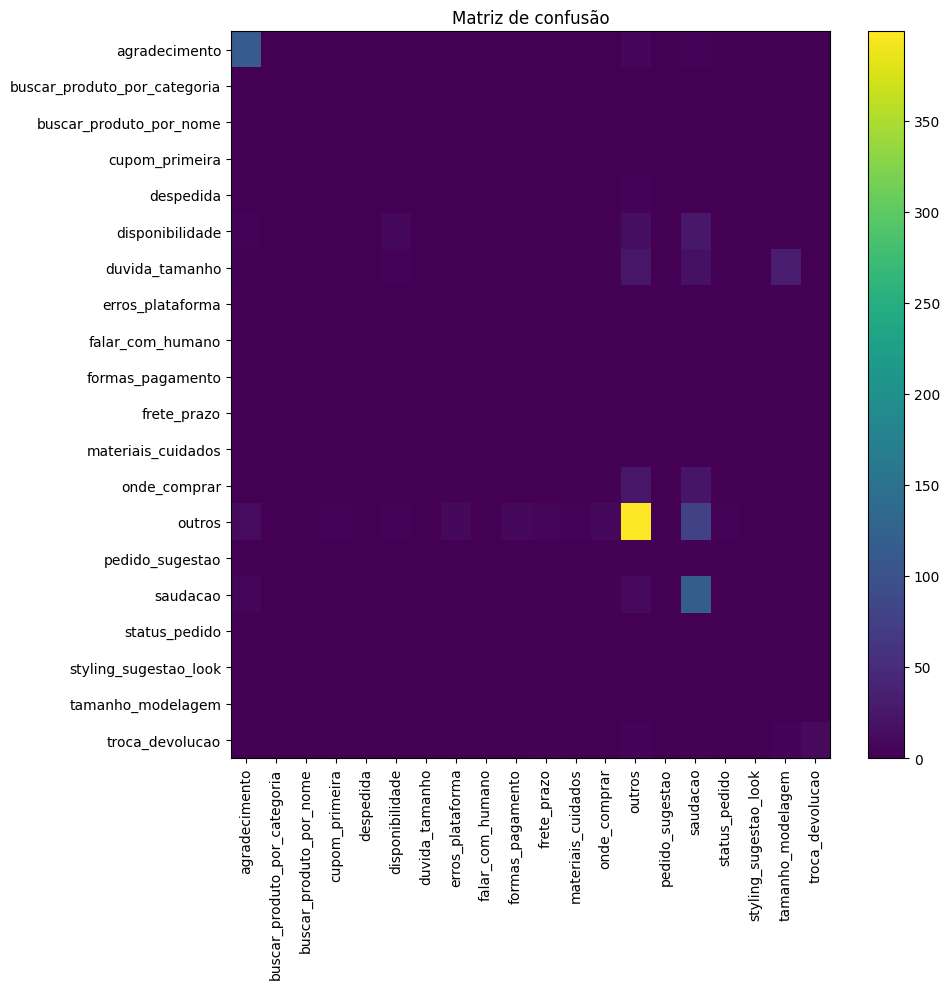

In [402]:
# CÉLULA 13 — Avaliação com NB03 (corrigida p/ path atual)
nb03_path = NOTEBOOKS_DIR / "outputs" / "notebook03_outputs" / "mensagens_rotulos_resumo.csv"

if not nb03_path.exists():
    print("NB03 não encontrado em:", nb03_path)
    print("→ Ajuste o caminho acima se seu NB03 estiver em outro lugar.")
else:
    df_raw = pd.read_csv(nb03_path)
    print("CSV NB03 encontrado. Colunas:", list(df_raw.columns))

    def pick_col(cols, aliases):
        for a in aliases:
            if a in cols:
                return a
        return None

    txt_col = pick_col(df_raw.columns, COL_ALIASES.get("texto", ["texto"]))
    lab_col = pick_col(df_raw.columns, COL_ALIASES.get("intent", ["label_regra","intent"]))
    assert txt_col and lab_col, "Ajuste column_aliases no label_map.yaml (texto/intent)."

    # normaliza intents (colapso → canônicas)
    df = df_raw[[txt_col, lab_col]].rename(columns={txt_col: "texto", lab_col: "intent"})
    df["intent"] = df["intent"].map(canon_label)

    if DROP_LABS:
        before = len(df)
        df = df[~df["intent"].isin(DROP_LABS)]
        if before - len(df):
            print(f"→ Removi {before-len(df)} linha(s) por DROP_LABS.")

    # mantém apenas intents do YAML
    df = df[df["intent"].isin(INTENTS_YAML)].reset_index(drop=True)

    # roda predição
    y_true, y_pred = [], []
    for txt, lab in df[["texto","intent"]].itertuples(index=False):
        r = respond(str(txt))
        y_true.append(lab); y_pred.append(r["intent"])

    from sklearn.metrics import classification_report, confusion_matrix
    labs = sorted(INTENTS_YAML)
    print("\n=== RELATÓRIO DE CLASSIFICAÇÃO ===")
    print(classification_report(y_true, y_pred, zero_division=0, labels=labs))

    print("\n=== MATRIZ DE CONFUSÃO (ordem = intents do YAML) ===\n")
    cm = confusion_matrix(y_true, y_pred, labels=labs)
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(10,10))
    im = ax.imshow(cm, aspect="auto")
    ax.set_xticks(range(len(labs))); ax.set_xticklabels(labs, rotation=90)
    ax.set_yticks(range(len(labs))); ax.set_yticklabels(labs)
    ax.set_title("Matriz de confusão")
    fig.colorbar(im, ax=ax)
    plt.tight_layout(); plt.show()


In [403]:
# CÉLULA 14 — Sweep thresholds
# Varre valores de THRESH e GAP_TOP2 para inspecionar sensibilidade de 'outros'.
# Útil para decidir política mais conservadora (menos falso-positivo) ou agressiva.

sample_msgs = [
    "oi bibi",
    "quero saber formas de pagamento",
    "qual o prazo de entrega pro CEP 04567-890?",
    "tem vestido M em estoque?",
    "meu pedido é 3F9A1B, qual o status?",
]
grid = []
for thr in [0.4, 0.5, 0.6]:
    for gap in [0.05, 0.10, 0.15, 0.20]:
        outros = 0
        preds = []
        for m in sample_msgs:
            intent_raw, conf, g = predict_ml(m)
            pred = "outros" if not (conf >= thr and g >= gap) else intent_raw
            preds.append(pred)
            if pred == "outros":
                outros += 1
        grid.append({"thr":thr, "gap":gap, "outros_rate": outros/len(sample_msgs), "preds": preds})

pd.DataFrame(grid)


,thr,gap,outros_rate,preds
0,0.4,0.05,0.0,"[saudacao, formas_pagamento, frete_prazo, saud..."
1,0.4,0.10,0.0,"[saudacao, formas_pagamento, frete_prazo, saud..."
2,0.4,0.15,0.0,"[saudacao, formas_pagamento, frete_prazo, saud..."
3,0.4,0.20,0.4,"[outros, formas_pagamento, frete_prazo, outros..."
4,0.5,0.05,0.0,"[saudacao, formas_pagamento, frete_prazo, saud..."
5,0.5,0.10,0.0,"[saudacao, formas_pagamento, frete_prazo, saud..."
6,0.5,0.15,0.0,"[saudacao, formas_pagamento, frete_prazo, saud..."
7,0.5,0.20,0.4,"[outros, formas_pagamento, frete_prazo, outros..."
8,0.6,0.05,0.6,"[outros, formas_pagamento, frete_prazo, outros..."
9,0.6,0.10,0.6,"[outros, formas_pagamento, frete_prazo, outros..."


In [404]:
# CÉLULA 15 — Debug linha a linha
# Mostra o "estado→estado" e a resposta sugerida para uma sequência simbólica de mensagens.

exs = [
    ("START", "oi bibi"),
    ("CAPTURA_INTENCAO", "quero saber formas de pagamento"),
    ("INFO_PAGAMENTO", "qual o prazo de entrega pro CEP 04567-890?"),
    ("ENCERRAMENTO", "tem vestido M em estoque?"),
    ("FALLBACK_PEDIR_REFORMULACAO", "meu pedido é 3F9A1B, qual o status?"),
]
rows = []
for st, msg in exs:
    r = respond(msg, st)
    rows.append(r)
pd.DataFrame(rows)


,state_in,texto,intent,intent_raw,conf,gap_top2,heuristica,entities,action,state_out,resposta_sugerida
0,START,oi bibi,saudacao,saudacao,0.5089,0.1742,rule:saudacao,{},None,CAPTURA_INTENCAO,Oi! Eu sou a BIBI da Curadobia. Posso calcular...
1,CAPTURA_INTENCAO,quero saber formas de pagamento,formas_pagamento,formas_pagamento,0.7894,0.6423,rule:formas_pagamento,{},None,INFO_PAGAMENTO,"Aceitamos PIX, boleto e cartão (com possibilid..."
2,INFO_PAGAMENTO,qual o prazo de entrega pro CEP 04567-890?,frete_prazo,frete_prazo,0.7557,0.6725,rule:frete_cep,{'geo.cep': '04567-890'},None,ENCERRAMENTO,"Foi um prazer ajudar! Se precisar, é só chamar. 👋"
3,ENCERRAMENTO,tem vestido M em estoque?,disponibilidade,saudacao,0.5833,0.1949,rule:estoque_cat,"{'tamanho_ref': 'm', 'categoria': 'vestido'}",None,FALLBACK_PEDIR_REFORMULACAO,Tô quase lá! Quer me dizer de outro jeitinho o...
4,FALLBACK_PEDIR_REFORMULACAO,"meu pedido é 3F9A1B, qual o status?",outros,nao_entendi,0.5005,0.2310,None,{},None,CAPTURA_INTENCAO,Oi! Eu sou a BIBI da Curadobia. Posso calcular...


In [405]:
# CÉLULA 16 — Checagem de consistência entre modelo e YAML (após colapso)
# Mapeia labels legados (ex.: 'nao_entendi', 'como_comprar') para canônicos via label_map → reduz “falsos faltantes”.

def _collapse_model_label(lbl: str) -> str:
    # reaproveita canon_label mas sem mandar p/ 'outros' se já for canônico desconhecido
    k = canon_label(lbl)
    return k

if LE is None:
    print("⚠️  Sem LabelEncoder do modelo — pulando checagem.")
else:
    raw_classes = list(map(str, LE.classes_))
    classes_modelo_colapsadas = set(_collapse_model_label(c) for c in raw_classes)

    faltando_no_modelo = sorted(INTENTS_YAML - classes_modelo_colapsadas)
    sobrando_no_modelo = sorted(classes_modelo_colapsadas - INTENTS_YAML)

    print("Intents no YAML   :", len(INTENTS_YAML))
    print("Intents no modelo :", len(classes_modelo_colapsadas))

    if faltando_no_modelo:
        print("⚠️  Intents NO YAML mas NÃO no modelo:", faltando_no_modelo)
    else:
        print("✓ Não há intents faltando no modelo (após colapso).")

    if sobrando_no_modelo:
        print("ℹ️  Intents que o modelo tem mas não estão no YAML (após colapso):", sobrando_no_modelo)
    else:
        print("✓ Não há intents sobrando no modelo (após colapso).")

    print("‘outros’ no modelo (após colapso)? ->", "sim" if "outros" in classes_modelo_colapsadas else "NÃO (considere treinar)")


Intents no YAML   : 20
Intents no modelo : 10
⚠️  Intents NO YAML mas NÃO no modelo: ['buscar_produto_por_categoria', 'buscar_produto_por_nome', 'cupom_primeira', 'despedida', 'disponibilidade', 'duvida_tamanho', 'falar_com_humano', 'materiais_cuidados', 'status_pedido', 'styling_sugestao_look']
✓ Não há intents sobrando no modelo (após colapso).
‘outros’ no modelo (após colapso)? -> sim


In [406]:
# CÉLULA 17 — Persistir thresholds (THRESH e GAP_TOP2) no thresholds.json
# Facilita reuso pelos outros notebooks/serviços (mesma pasta MODELOS_DIR).

def salvar_thresholds(threshold: float, gap_top2: float, path: Path = MODELOS_DIR / "thresholds.json"):
    meta = {"threshold": float(threshold), "gap_top2": float(gap_top2)}
    path.write_text(json.dumps(meta, ensure_ascii=False, indent=2), encoding="utf-8")
    print(f"✓ thresholds salvos em {path} ->", meta)

# Exemplo: use os valores atuais carregados
salvar_thresholds(THRESH, GAP_TOP2)


✓ thresholds salvos em c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\modelos\thresholds.json -> {'threshold': 0.5, 'gap_top2': 0.1}


In [407]:
# CÉLULA 18 — Batch-teste rápido: passe uma lista de frases e veja o diagnóstico
# Ferramenta de inspeção para times de negócio: avalia múltiplas mensagens em uma tacada.

def testar_mensagens(msgs, state="START"):
    rows = []
    for m in msgs:
        rows.append(respond(str(m), curr_state=state))
    df = pd.DataFrame(rows)
    display(df[["state_in","texto","intent","intent_raw","conf","gap_top2","heuristica","entities","state_out","resposta_sugerida"]])
    return df

# Exemplo de uso:
_ = testar_mensagens([
    "oi bibi",
    "quero saber formas de pagamento",
    "qual o prazo de entrega pro CEP 04567-890?",
    "tem vestido M em estoque?",
    "meu pedido é 3F9A1B, qual o status?",
])


,state_in,texto,intent,intent_raw,conf,gap_top2,heuristica,entities,state_out,resposta_sugerida
0,START,oi bibi,saudacao,saudacao,0.5089,0.1742,rule:saudacao,{},CAPTURA_INTENCAO,Oi! Eu sou a BIBI da Curadobia. Posso calcular...
1,START,quero saber formas de pagamento,formas_pagamento,formas_pagamento,0.7894,0.6423,rule:formas_pagamento,{},CAPTURA_INTENCAO,Oi! Eu sou a BIBI da Curadobia. Posso calcular...
2,START,qual o prazo de entrega pro CEP 04567-890?,frete_prazo,frete_prazo,0.7557,0.6725,rule:frete_cep,{'geo.cep': '04567-890'},CAPTURA_INTENCAO,Oi! Eu sou a BIBI da Curadobia. Posso calcular...
3,START,tem vestido M em estoque?,disponibilidade,saudacao,0.5833,0.1949,rule:estoque_cat,"{'tamanho_ref': 'm', 'categoria': 'vestido'}",CAPTURA_INTENCAO,Oi! Eu sou a BIBI da Curadobia. Posso calcular...
4,START,"meu pedido é 3F9A1B, qual o status?",outros,nao_entendi,0.5005,0.2310,None,{},CAPTURA_INTENCAO,Oi! Eu sou a BIBI da Curadobia. Posso calcular...


In [408]:
# CÉLULA 19 — Quais pares (verdadeiro → previsto) mais confundem? (FIX do colapso)
# Mostra TOP confusões e exemplos (diagnóstico para curadoria/novo rotulador).

nb03_path = NOTEBOOKS_DIR / "outputs" / "notebook03_outputs" / "mensagens_rotulos_resumo.csv"
if not nb03_path.exists():
    print("NB03 não encontrado em:", nb03_path)
else:
    df_raw = pd.read_csv(nb03_path)

    def pick_col(cols, aliases):
        for a in aliases:
            if a in cols:
                return a
        return None

    txt_col = pick_col(df_raw.columns, COL_ALIASES.get("texto", ["texto"]))
    lab_col = pick_col(df_raw.columns, COL_ALIASES.get("intent", ["label_regra","intent"]))
    assert txt_col and lab_col, "Ajuste column_aliases no label_map.yaml (texto/intent)."

    # Normaliza rótulo verdadeiro com a mesma lógica de colapso/canônico
    def _norm_key_basic(s: str) -> str:
        if not isinstance(s, str):
            return ""
        key = s.strip().lower()
        if LABELMAP.get("normalize", {}).get("strip_accents"):
            import unicodedata
            key = "".join(c for c in unicodedata.normalize("NFD", key) if unicodedata.category(c) != "Mn")
        if LABELMAP.get("normalize", {}).get("casefold"):
            key = key.casefold()
        for src, dst in LABELMAP.get("normalize", {}).get("replace", {}).items():
            key = key.replace(src, dst)
        key = re.sub(r"\s+", "_", key)
        return key

    def _collapse_safe(key: str) -> str:
        k = _norm_key_basic(key)
        if isinstance(COLLAPSE, dict):
            for canon, variants in COLLAPSE.items():
                varlist = variants if isinstance(variants, (list, tuple, set)) else []
                if k == canon or k in [_norm_key_basic(v) for v in varlist]:
                    return canon
        return k

    def canon(label: str) -> str:
        k = _collapse_safe(label)
        if k not in INTENTS_YAML:
            return LABELMAP.get("unknown_to", "outros")
        return k

    dfe = df_raw[[txt_col, lab_col]].rename(columns={txt_col:"texto", lab_col:"label_true"}).copy()
    dfe["label_true"] = dfe["label_true"].astype(str).map(canon)
    dfe = dfe[dfe["label_true"].isin(INTENTS_YAML)]

    preds, raws, confs, gaps = [], [], [], []
    for t in dfe["texto"].astype(str):
        iraw, c, g = predict_ml(t)
        pred = choose_intent(iraw, c, g)
        preds.append(pred); raws.append(iraw); confs.append(c); gaps.append(g)

    dfe["intent_pred"] = preds
    dfe["intent_raw"]  = raws
    dfe["conf"]        = confs
    dfe["gap"]         = gaps

    confusoes = (dfe[dfe["label_true"] != dfe["intent_pred"]]
                 .groupby(["label_true","intent_pred"])
                 .size().reset_index(name="qtd")
                 .sort_values("qtd", ascending=False))
    display(confusoes.head(15))

    TOPN = 5
    for _, row in confusoes.head(TOPN).iterrows():
        lt, ip = row["label_true"], row["intent_pred"]
        print(f"\n===== {lt}  →  {ip}  (qtd={row['qtd']}) =====")
        samp = dfe[(dfe["label_true"]==lt) & (dfe["intent_pred"]==ip)].head(5)
        display(samp[["texto","label_true","intent_raw","conf","gap","intent_pred"]])


,label_true,intent_pred,qtd
25,outros,nao_entendi,234
26,outros,saudacao,84
8,disponibilidade,saudacao,28
13,duvida_tamanho,tamanho_modelagem,26
10,duvida_tamanho,nao_entendi,24
19,onde_comprar,saudacao,22
18,onde_comprar,outros,19
11,duvida_tamanho,outros,18
1,agradecimento,outros,17
35,saudacao,outros,16



===== outros  →  nao_entendi  (qtd=234) =====


,texto,label_true,intent_raw,conf,gap,intent_pred
6,como falo com alguém daí,outros,nao_entendi,0.755392,0.569992,nao_entendi
8,mas a peça ainda não chegou,outros,nao_entendi,0.856929,0.770624,nao_entendi
10,com quem falo b,outros,nao_entendi,0.570827,0.162638,nao_entendi
11,???,outros,nao_entendi,0.741182,0.504071,nao_entendi
13,chegou,outros,nao_entendi,0.744345,0.533850,nao_entendi



===== outros  →  saudacao  (qtd=84) =====


,texto,label_true,intent_raw,conf,gap,intent_pred
28,"somos uma produtora de áudio visual, e achamos...",outros,saudacao,0.538031,0.257388,saudacao
36,feliz demais q vc gostou ! ☺️☺️☺️ me fala como...,outros,saudacao,0.791126,0.612006,saudacao
39,acho ótimo. pode ser segunda 29 na parte da ta...,outros,saudacao,0.567371,0.270970,saudacao
56,boa tarde! na página da regata podrinha cinza ...,outros,saudacao,0.766392,0.566476,saudacao
75,bia gosto muito das suas bolsas . poderia pass...,outros,saudacao,0.756774,0.672308,saudacao


...

,texto,label_true,intent_raw,conf,gap,intent_pred
35,ola bia sou a daniela e gostaria de apresentar...,disponibilidade,saudacao,0.879873,0.796298,saudacao
153,"amoooo suas rasteiras, não são da sua lj, mas ...",disponibilidade,saudacao,0.645710,0.532207,saudacao
164,"bom dia! gostaria de adquirir essa calça, mas ...",disponibilidade,saudacao,0.665646,0.515795,saudacao
166,oiii! tudo bem? me chamo caroline sou formada ...,disponibilidade,saudacao,0.669417,0.484378,saudacao
200,"bom dia! sou a gianina marques, mineira, mãe e...",disponibilidade,saudacao,0.737003,0.609446,saudacao



===== duvida_tamanho  →  tamanho_modelagem  (qtd=26) =====


,texto,label_true,intent_raw,conf,gap,intent_pred
62,gostaria de saber o tamanho da cintura dessa c...,duvida_tamanho,tamanho_modelagem,0.881050,0.828712,tamanho_modelagem
129,gosto da calça assim mais curta! visto entre 3...,duvida_tamanho,tamanho_modelagem,0.550214,0.273416,tamanho_modelagem
135,já tentei três vezes. será que pode ser o tama...,duvida_tamanho,tamanho_modelagem,0.939980,0.915396,tamanho_modelagem
136,gostaria de saber qual a altura e medidas da b...,duvida_tamanho,tamanho_modelagem,0.880584,0.797433,tamanho_modelagem
146,"bom dia. estou interessada na blusa pah, mas e...",duvida_tamanho,tamanho_modelagem,0.868857,0.803734,tamanho_modelagem



===== duvida_tamanho  →  nao_entendi  (qtd=24) =====


,texto,label_true,intent_raw,conf,gap,intent_pred
60,a calça ficou sobrando muito atrás.,duvida_tamanho,nao_entendi,0.854551,0.803149,nao_entendi
147,m,duvida_tamanho,nao_entendi,0.877354,0.788666,nao_entendi
245,teria as medidas do 42,duvida_tamanho,nao_entendi,0.858197,0.781261,nao_entendi
246,"pois sou , em algumas marcas , 44",duvida_tamanho,nao_entendi,0.754086,0.672991,nao_entendi
247,"e em outras , 42",duvida_tamanho,nao_entendi,0.862123,0.784224,nao_entendi


In [409]:
# CÉLULA 20 — Exporta misclassifications para OUTBOX (rótulo verdadeiro, previsto, etc.)
# Artefato principal para retraining/rotulagem assistida.

if 'dfe' in globals():
    err = dfe[dfe["label_true"] != dfe["intent_pred"]].copy()
    cols = ["texto","label_true","intent_raw","conf","gap","intent_pred"]
    err = err[cols].sort_values(["label_true","intent_pred","conf"], ascending=[True, True, False])
    out_err = OUTBOX / "misclassified_for_retrain.csv"
    err.to_csv(out_err, index=False, encoding="utf-8")
    print("✓ Misclassifications exportadas para:", out_err, f"(linhas={len(err)})")
else:
    print("Rodar antes a CÉLULA 19 para gerar 'dfe'.")


✓ Misclassifications exportadas para: c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\notebook07_outputs\misclassified_for_retrain.csv (linhas=652)


# 🧭 Curadoria Orientada por Erros (misclassifications → melhorias rápidas)

Use este roteiro para **corrigir o que mais dói** antes de reprocessar o dataset.

## 1) Ataque os pares mais confusos
- Olhe a **“MATRIZ DE CONFUSÃO”** e o ranking de pares (CÉLULA 19).
- Para cada par **(verdadeiro → previsto)** no topo:
  - Abra `misclassified_for_retrain.csv` (OUTBOX) e **colete exemplos**.
  - Decida: é alias? **Adicione ao `collapse_to`** (NB08 ajuda a sugerir).
  - É texto ambíguo? Sinalize para **rever template/estado** no YAML.

## 2) Revise os thresholds
- Varra `THRESH` × `GAP_TOP2` (CÉLULA 14). Busque:
  - **Menos “outros”** sem inflar confusão.
  - Gap alto reduz “empates” entre classes.
- Critério rápido:
  - Se `outros_rate` > 30%: **baixe THRESH** ou enriqueça `collapse_to`.
  - Se há muitas confusões “irmãs”: **suba GAP_TOP2**.

## 3) Balanceie → reavalie
- Gere `balanced_nb03_for_training.csv` (CÉLULA 21).
- Refaça a avaliação (CÉLULA 13) e confira se os **pares críticos** caíram.

## 4) Aceite mudanças com critérios
- Acurácia macro ↑ **e** `outros` estável/menor.
- Sem piorar intents críticas (pagamento, frete, status).
- Diff do `collapse_to` versionado (git) e **anotado no PR**.

> Ordem de ouro: **(a) ajustar colapsos** → **(b) thresholds** → **(c) reequilibrar**. Só então pense em **trocar embedder/classificador**.


In [410]:
# CÉLULA 21 — Gera um conjunto rotulado balanceado (subamostragem) para (re)treino/validação
# Evita overfitting em classes majoritárias (cap em max_por_classe).

def balancear_por_classe(df, label_col="label_true", max_por_classe=200, seed=42):
    np.random.seed(seed)
    parts = []
    for lab, grp in df.groupby(label_col):
        if len(grp) > max_por_classe:
            parts.append(grp.sample(max_por_classe, random_state=seed))
        else:
            parts.append(grp)
    return pd.concat(parts, ignore_index=True)

if 'dfe' in globals():
    balanced = balancear_por_classe(dfe[["texto","label_true"]], label_col="label_true", max_por_classe=200)
    out_bal = OUTBOX / "balanced_nb03_for_training.csv"
    balanced.to_csv(out_bal, index=False, encoding="utf-8")
    print(f"✓ Conjunto balanceado salvo em: {out_bal} (linhas={len(balanced)})")
else:
    print("Rodar antes a CÉLULA 19 para gerar 'dfe'.")


✓ Conjunto balanceado salvo em: c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\notebook07_outputs\balanced_nb03_for_training.csv (linhas=687)


In [411]:
# CÉLULA 22 — Sanity de paths para continuar no NB05
# Garante pastas padrão para outros notebooks (NB05 etc.), mesmo se variáveis "sumirem" do escopo.

from pathlib import Path
import os, sys, platform

def _fallback_paths():
    REPO_ROOT = Path(".").resolve()
    CODE_DIR  = REPO_ROOT / "code"
    NOTEBOOKS_DIR = CODE_DIR / "notebooks"
    INBOX  = NOTEBOOKS_DIR / "notebook05_inputs"
    OUTBOX = NOTEBOOKS_DIR / "notebook05_outputs"
    for p in (INBOX, OUTBOX):
        p.mkdir(parents=True, exist_ok=True)
    return REPO_ROOT, CODE_DIR, NOTEBOOKS_DIR, INBOX, OUTBOX

if "REPO_ROOT" not in globals():
    REPO_ROOT, CODE_DIR, NOTEBOOKS_DIR, INBOX, OUTBOX = _fallback_paths()

RESOURCES_DIR = CODE_DIR / "resources"
print("SO:", platform.platform())
print("REPO_ROOT:", REPO_ROOT)
print("INBOX    :", INBOX)
print("OUTBOX   :", OUTBOX)
print("RESOURCES:", RESOURCES_DIR)


SO: Windows-11-10.0.26100-SP0
REPO_ROOT: c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04
INBOX    : c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\notebook07_inputs
OUTBOX   : c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\notebook07_outputs
RESOURCES: c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\resources


In [412]:
# CÉLULA 23 — Checa e, se necessário, patch engine.py e service.py (idempotente)
# Razão: manter API previsível (next_state → (next, action)) e templating mínimo no service.
# PATCHES são escritos apenas se necessário (não poluem se já estiverem OK).

from pathlib import Path
import importlib, inspect

ENGINE_FILE  = CODE_DIR / "fluxos_intencao" / "engine.py"
SERVICE_FILE = CODE_DIR / "fluxos_intencao" / "service.py"

# Detecta se engine.next_state já retorna (next_state, action)
needs_engine_patch = False
try:
    from code.fluxos_intencao.yaml_loader import load_yaml
    from code.fluxos_intencao.engine import Engine
    import yaml
    raw = load_yaml(RESOURCES_DIR / "fluxos.yaml")
    eng = Engine(raw)
    _res = eng.next_state("START", "saudacao", {})
    if not isinstance(_res, tuple):
        needs_engine_patch = True
except Exception:
    needs_engine_patch = True

# Detecta se service tem templating (procura assinatura interna)
needs_service_patch = False
try:
    import code.fluxos_intencao.service as svmod
    src = Path(svmod.__file__).read_text(encoding="utf-8")
    if "_render_template_str" not in src or "def _run_action" not in src:
        needs_service_patch = True
except Exception:
    needs_service_patch = True

print("Precisa patch engine? ", needs_engine_patch)
print("Precisa patch service?", needs_service_patch)

# Patches (mesmos que já te enviei, reescritos aqui)
if needs_engine_patch:
    ENGINE_FILE.write_text('''
from dataclasses import asdict, is_dataclass

class Engine:
    def __init__(self, graph):
        self.graph = self._coerce_to_dict(graph)
        self.states    = self.graph.get("states", {}) or {}
        self.templates = self.graph.get("templates", {}) or {}
        self.fallbacks = self.graph.get("fallbacks", {}) or {}

    def _coerce_to_dict(self, graph):
        if isinstance(graph, dict):
            return graph
        if hasattr(graph, "to_dict") and callable(graph.to_dict):
            return graph.to_dict()
        if is_dataclass(graph):
            return asdict(graph)
        if hasattr(graph, "__dict__"):
            d = {}
            for k in ("states", "templates", "intents", "entities", "fallbacks"):
                if hasattr(graph, k):
                    d[k] = getattr(graph, k)
            return d or dict(graph.__dict__)
        try:
            return dict(graph)
        except Exception:
            raise TypeError(f"Tipo de grafo não suportado: {type(graph)}")

    def _eval_guard(self, guard: str, ctx: dict) -> bool:
        if not guard:
            return True
        g = guard.strip()
        neg = g.startswith("not(") or g.startswith("!has")
        key = g.replace("not(", "").replace(")", "").replace("!", "")
        key = key.replace("has(", "").replace(")", "")
        slots = ctx.get("slots", {}) if isinstance(ctx, dict) else {}
        has  = bool(ctx.get(key) or slots.get(key))
        return (not has) if neg else has

    def match_transition(self, state: str, intent: str, ctx: dict):
        trans = (self.states.get(state, {}) or {}).get("transitions", []) or []
        for t in trans:
            t_int = t.get("intent", "any")
            if t_int not in ("any", intent):
                continue
            if not self._eval_guard(t.get("guard"), ctx or {}):
                continue
            return t
        fb = (self.fallbacks or {}).get("on_unrecognized_intent")
        if fb:
            return {"intent": "any", "next": fb.get("next", state), "action": None}
        return None

    def next_state(self, state: str, intent: str, ctx: dict):
        t = self.match_transition(state, intent, ctx or {})
        if not t:
            return state, None
        return t.get("next", state), t.get("action")

    def entry_template_key(self, state: str):
        st = self.states.get(state, {}) or {}
        return (st.get("entry", {}) or {}).get("template")

    def entry_text(self, state: str) -> str:
        key = self.entry_template_key(state)
        return (self.templates or {}).get(key, "") if key else ""
''', encoding="utf-8")
    print("✓ engine.py patch aplicado.")

if needs_service_patch:
    SERVICE_FILE.write_text('''
from .config import Config
from .yaml_loader import load_yaml
from .engine import Engine
import re

_CATS = {"vestido","blusa","calca","saia","macaquinho","casaco","acessorio","outro"}
_TAMS = {"pp","p","m","g","gg","xg","xxg","36","38","40","42","44","46"}
_RE_CEP    = re.compile(r"\\b(\\d{5})-?(\\d{3})\\b")
_RE_PEDIDO = re.compile(r"\\b([A-Z0-9]{5,10})\\b", re.I)

def _extract_entities(texto: str):
    ents = {}
    if not isinstance(texto, str):
        return ents
    t = texto.strip()
    m = _RE_CEP.search(t)
    if m:
        ents["geo.cep"] = f"{m.group(1)}-{m.group(2)}"
    if "pedido" in t.lower():
        m2 = _RE_PEDIDO.search(t)
        if m2:
            ents["pedido.id"] = m2.group(1).upper()
    m3 = re.search(r"\\btam(?:anho)?[: ]?([pxmg]{1,2}|\\d{2})\\b", t, flags=re.I)
    if m3:
        ents["tamanho_ref"] = m3.group(1).lower()
    else:
        for tm in _TAMS:
            if re.search(rf"\\b{re.escape(tm)}\\b", t, flags=re.I):
                ents["tamanho_ref"] = tm
                break
    for c in _CATS:
        if re.search(rf"\\b{re.escape(c)}\\b", t, flags=re.I):
            ents["categoria"] = c
            break
    return ents

def _render_template_str(tpl: str, ctx: dict) -> str:
    if not tpl:
        return ""
    text = str(tpl)
    slots = (ctx or {}).get("slots", {}) if isinstance(ctx, dict) else {}
    flat = dict(ctx or {})
    flat.update(slots)
    for k, v in flat.items():
        text = text.replace("{{"+str(k)+"}}", str(v))
    return text

class _RuleBasedNLU:
    def predict(self, text: str):
        s = (text or "").lower()
        def has_any(words): return any(w in s for w in words)
        if has_any(["oi","olá","ola","bom dia","boa tarde","boa noite"]): intent="saudacao"
        elif has_any(["tamanho","serve","medida","manequim","numeracao","numeração"]): intent="tamanho_modelagem"
        elif has_any(["frete","prazo","entrega","cep"]): intent="frete_prazo"
        elif has_any(["preço","preco","pix","cartão","cartao","boleto","pagar","pagamento"]): intent="formas_pagamento"
        elif has_any(["estoque","disponível","disponivel","tem no tamanho","tem tamanho","tem cor"]): intent="disponibilidade"
        elif has_any(["onde comprar","link","comprar","quero comprar"]): intent="onde_comprar"
        elif has_any(["humano","atendente","pessoa"]): intent="falar_com_humano"
        elif has_any(["tchau","obrigado","valeu"]): intent="despedida"
        else: intent="outros"
        return {"intent": intent, "conf": 1.0, "probs": {}, "top1": intent, "top2": intent, "gap": 1.0}

class ChatService:
    def __init__(self):
        self.cfg    = Config.from_env()
        raw         = load_yaml(self.cfg.fluxos_yaml)
        self.engine = Engine(raw)
        self.state  = "START"
        self.ctx    = {"slots": {}}
        try:
            from .nlu import IntentClassifier
            self.nlu = IntentClassifier(
                models_dir=self.cfg.models_dir,
                embedder_name=self.cfg.hf_embedder,
                intent_threshold=self.cfg.intent_threshold,
                top2_gap=self.cfg.intent_top2_gap,
                fallback_label=self.cfg.fallback_label or "outros",
            )
        except Exception:
            self.nlu = _RuleBasedNLU()

    def _run_action(self, action_name: str):
        if not action_name:
            return {}
        try:
            from . import actions as _actions
            fn = getattr(_actions, action_name, None)
            if callable(fn):
                return fn(dict(self.ctx)) or {}
        except Exception:
            return {}
        return {}

    def handle(self, user_text: str, ctx: dict | None = None):
        if isinstance(ctx, dict):
            self.ctx.update({k:v for k,v in ctx.items() if k != "slots"})
            if "slots" in ctx and isinstance(ctx["slots"], dict):
                self.ctx["slots"].update(ctx["slots"])
        ents = _extract_entities(user_text or "")
        self.ctx.update(ents)
        self.ctx.setdefault("slots", {}).update(ents)

        pred   = self.nlu.predict(user_text)
        intent = pred.get("intent") or "outros"

        ns, act = self.engine.next_state(self.state, intent, self.ctx)
        if ns == "CAPTURA_INTENCAO":
            ns, act = self.engine.next_state(ns, intent, self.ctx)

        if act:
            out = self._run_action(act)
            if isinstance(out, dict):
                self.ctx.update(out)
                self.ctx.setdefault("slots", {}).update(out)

        tpl_key = self.engine.entry_template_key(ns)
        if tpl_key:
            tpl_text = (self.engine.templates or {}).get(tpl_key, "")
            reply = _render_template_str(tpl_text, self.ctx) or "..."
        else:
            reply = self.engine.entry_text(ns) or "..."

        self.state = ns
        meta  = {"estado": self.state, "intencao": intent, "acao": act}
        return reply, meta
''', encoding="utf-8")
    print("✓ service.py patch aplicado.")

# recarrega módulos (precaução)
import importlib
importlib.invalidate_caches()


Precisa patch engine?  True
Precisa patch service? True
✓ engine.py patch aplicado.
✓ service.py patch aplicado.


In [413]:
# CÉLULA 24 — Normaliza catálogo e prepara DataFrame
# O catálogo abastece ações/templates que precisam de contexto de produtos.
# Mantém múltiplas fontes candidatas + normalizações leves de colunas/chaves.

import pandas as pd, re, unicodedata

# prioridades de origem
CANDIDATES = [
    OUTBOX / "catalogo_normalizado.parquet",
    INBOX  / "catalogo.csv",
    INBOX  / "catalogo.parquet",
    INBOX  / "catalogo.xlsx",
    Path("/mnt/data/Base produtos Curadobia.xlsx"),  # se existir
]

src = next((c for c in CANDIDATES if c.exists()), None)
print("Catálogo origem:", src)

if src is None:
    # Mock mínimo — útil para smoke tests da pipeline
    df_raw = pd.DataFrame([
        {"sku":"VEST001","nome":"Vestido midi alfaiataria","categoria":"vestido","preco":590.0,"cor":"preto","tamanhos":"P,M,G","tecido":"alfaiataria","elasticidade":"baixa","estoque":12,"descricao":"Vestido midi de alfaiataria para trabalho e eventos"},
        {"sku":"BLUS002","nome":"Blusa cetim gola laço","categoria":"blusa","preco":329.0,"cor":"off","tamanhos":"P,M,G,GG","tecido":"cetim","elasticidade":"media","estoque":7,"descricao":"Blusa de cetim leve, ótima para trabalho e jantar"},
        {"sku":"CALS003","nome":"Calça pantalona linho","categoria":"calca","preco":489.0,"cor":"areia","tamanhos":"PP,P,M,G","tecido":"linho","elasticidade":"baixa","estoque":5,"descricao":"Pantalona de linho com caimento elegante"},
    ])
    print("⚠️  Usando catálogo mock (crie INBOX/catalogo.csv para usar o real).")
else:
    if src.suffix.lower()==".parquet":
        df_raw = pd.read_parquet(src)
    elif src.suffix.lower()==".csv":
        df_raw = pd.read_csv(src)
    elif src.suffix.lower() in (".xlsx",".xls"):
        try:
            df_raw = pd.read_excel(src)
        except Exception as e:
            print("⚠️ Falha ao abrir XLSX. Salve como CSV em notebook05_inputs/catalogo.csv. Erro:", e)
            df_raw = pd.DataFrame()

def strip_acc(s): 
    return "".join(c for c in unicodedata.normalize("NFD", str(s)) if unicodedata.category(c)!="Mn")

def norm_key(s):
    s = strip_acc(s).lower().strip()
    return re.sub(r"\s+", "_", s)

df = df_raw.copy()
df.columns = [norm_key(c) for c in df.columns]

def pick(cols, names):
    for n in names:
        if n in cols: return n
    return None

colmap = {
    "sku": pick(df.columns, ["sku","id","codigo","código"]),
    "nome": pick(df.columns, ["nome","produto","titulo","título","name"]),
    "categoria": pick(df.columns, ["categoria","categoria_nome","tipo"]),
    "preco": pick(df.columns, ["preco","preço","price","valor"]),
    "cor": pick(df.columns, ["cor","color"]),
    "tamanhos": pick(df.columns, ["tamanhos","tamanho","tamanhos_disponiveis","grade","variacoes","variações"]),
    "tecido": pick(df.columns, ["tecido","material","composicao","composição"]),
    "elasticidade": pick(df.columns, ["elasticidade","stretch"]),
    "estoque": pick(df.columns, ["estoque","qtd","quantidade","disponivel","disponível"]),
    "descricao": pick(df.columns, ["descricao","descrição","description","detalhes"]),
}

import numpy as np
for k,v in colmap.items():
    if v is None:
        # cria coluna vazia (evita KeyError) e registra mapeamento
        df[f"__{k}__"] = np.nan
        colmap[k] = f"__{k}__"

cat_map = {"calça":"calca","acessório":"acessorio"}
def norm_cat(s):
    s = strip_acc(str(s or "")).lower().strip().replace(" ", "_")
    s = cat_map.get(s, s)
    if s not in {"vestido","blusa","calca","saia","macaquinho","casaco","acessorio","outro"}:
        s = "outro"
    return s

def norm_color(s):
    return strip_acc(str(s or "")).lower().strip()

def norm_sizes(s):
    s = strip_acc(str(s or ""))
    s = re.sub(r"[^0-9a-z,;/\- ]","", s.lower()).replace(";",",").replace("/",",").replace("-",",")
    toks = [t.strip() for t in s.split(",") if t.strip()]
    repl = {"pp":"pp","p":"p","m":"m","g":"g","gg":"gg","xg":"xg","xxg":"xxg"}
    out = [repl.get(t,t) for t in toks]
    # mantém ordem de aparição (de-dup estável)
    seen, out2 = set(), []
    for t in out:
        if t not in seen:
            out2.append(t); seen.add(t)
    return ",".join(out2)

df_norm = pd.DataFrame({
    "sku": df[colmap["sku"]].astype(str).str.strip(),
    "nome": df[colmap["nome"]].astype(str).str.strip(),
    "categoria": df[colmap["categoria"]].map(norm_cat),
    "preco": pd.to_numeric(df[colmap["preco"]], errors="coerce"),
    "cor": df[colmap["cor"]].map(norm_color),
    "tamanhos": df[colmap["tamanhos"]].map(norm_sizes),
    "tecido": df[colmap["tecido"]].astype(str).fillna(""),
    "elasticidade": df[colmap["elasticidade"]].astype(str).fillna(""),
    "estoque": pd.to_numeric(df[colmap["estoque"]], errors="coerce").fillna(0).astype(int),
    "descricao": df[colmap["descricao"]].astype(str).fillna(""),
}).drop_duplicates(subset=["sku"]).reset_index(drop=True)

print("df_norm:", df_norm.shape)
df_norm.head(5)


Catálogo origem: c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\notebook07_outputs\catalogo_normalizado.parquet
df_norm: (3, 10)


,sku,nome,categoria,preco,cor,tamanhos,tecido,elasticidade,estoque,descricao
0,VEST001,Vestido midi alfaiataria,vestido,590.0,preto,"p,m,g",alfaiataria,baixa,12,Vestido midi de alfaiataria para trabalho e ev...
1,BLUS002,Blusa cetim gola laço,blusa,329.0,off,"p,m,g,gg",cetim,media,7,"Blusa de cetim leve, ótima para trabalho e jantar"
2,CALS003,Calça pantalona linho,calca,489.0,areia,"pp,p,m,g",linho,baixa,5,Pantalona de linho com caimento elegante


In [414]:
# CÉLULA 25 — Salvar catálogo (parquet se disponível; fallback CSV)
# Além de salvar, cria um 'pointer' para apontar qual formato foi usado (debug-friendly).

from pathlib import Path

parq = OUTBOX / "catalogo_normalizado.parquet"
csv  = OUTBOX / "catalogo_normalizado.csv"

saved_path = None
try:
    df_norm.to_parquet(parq, index=False)
    saved_path = parq
    print("✓ Salvo em parquet:", parq)
except Exception as e:
    print("⚠️ Parquet indisponível. Motivo:", e)
    df_norm.to_csv(csv, index=False, encoding="utf-8")
    saved_path = csv
    print("✓ Salvo em CSV:", csv)

POINTER = OUTBOX / "catalogo_pointer.txt"
POINTER.write_text(str(saved_path), encoding="utf-8")
print("→ pointer:", POINTER.read_text(encoding="utf-8"))


✓ Salvo em parquet: c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\notebook07_outputs\catalogo_normalizado.parquet
→ pointer: c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\notebook07_outputs\catalogo_normalizado.parquet


In [415]:
# CÉLULA 26 — Patch em actions.py para suportar parquet OU csv
# Permite que funções de ação carreguem catálogo sem saber o formato previamente.

from pathlib import Path
import re

ACTIONS_FILE = CODE_DIR / "fluxos_intencao" / "actions.py"
src = ACTIONS_FILE.read_text(encoding="utf-8")

# garante imports básicos
if "import pandas as pd" not in src:
    src = "import pandas as pd\n" + src
if "from pathlib import Path" not in src:
    src = "from pathlib import Path\n" + src
if "from typing import Dict, Any" not in src:
    src = "from typing import Dict, Any\n" + src

# injeta variáveis globais para paths do catálogo (se ainda não existirem)
if "_PARQ" not in src or "_CSV" not in src:
    header_block = r'''
# === Catálogo normalizado: paths padrão (NB05 outputs) ===
_CAT_DF = None
_BASE   = Path(__file__).resolve().parents[1] / "notebooks" / "notebook05_outputs"
_PARQ   = _BASE / "catalogo_normalizado.parquet"
_CSV    = _BASE / "catalogo_normalizado.csv"
'''
    src = re.sub(r"(\n)(def\s|\Z)", header_block + r"\2", src, count=1, flags=re.S)

# corpo novo da função _load_catalog (lê parquet OU csv)
load_func = r'''
def _load_catalog() -> pd.DataFrame:
    """Carrega catálogo normalizado de parquet ou CSV (fallback)."""
    global _CAT_DF
    if _CAT_DF is not None:
        return _CAT_DF
    if _PARQ.exists():
        _CAT_DF = pd.read_parquet(_PARQ)
    elif _CSV.exists():
        _CAT_DF = pd.read_csv(_CSV)
    else:
        # fallback mínimo para não quebrar
        _CAT_DF = pd.DataFrame([
            {"sku":"VEST001","nome":"Vestido midi alfaiataria","categoria":"vestido","preco":590.0,"cor":"preto","tamanhos":"P,M,G","tecido":"alfaiataria","elasticidade":"baixa","estoque":12,"descricao":"Vestido midi de alfaiataria para trabalho e eventos"},
            {"sku":"BLUS002","nome":"Blusa cetim gola laço","categoria":"blusa","preco":329.0,"cor":"off","tamanhos":"P,M,G,GG","tecido":"cetim","elasticidade":"media","estoque":7,"descricao":"Blusa cetim leve, ótima para trabalho e jantar"},
        ])
    return _CAT_DF
'''

# substitui a função _load_catalog() inteira (se existir), ou adiciona
if "def _load_catalog(" in src:
    src = re.sub(
        r"def _load_catalog\([^\)]*\):.*?^\s*return _CAT_DF\s*$",
        load_func.strip(),
        src,
        flags=re.S|re.M
    )
else:
    src += "\n\n" + load_func.strip() + "\n"

ACTIONS_FILE.write_text(src, encoding="utf-8")
print("✓ actions.py atualizado para parquet/CSV.")


✓ actions.py atualizado para parquet/CSV.


In [416]:
# CÉLULA 27 — Adiciona template 'sugestoes_result' e entry em RECOMENDAR (idempotente)
# Também padroniza action calcular_frete → cotar_frete, se necessário.

import yaml
YAML_FILE = RESOURCES_DIR / "fluxos.yaml"
doc = yaml.safe_load(YAML_FILE.read_text(encoding="utf-8"))

doc.setdefault("templates", {})
if "sugestoes_result" not in doc["templates"]:
    doc["templates"]["sugestoes_result"] = "Separei {{n}} sugestões para você: {{lista_sugestoes}}. Posso te enviar os links? ✨"
    print("✓ Template 'sugestoes_result' adicionado.")
else:
    print("Template 'sugestoes_result' já existia.")

doc.setdefault("states", {})
rec = doc["states"].get("RECOMENDAR", {}) or {}
if "entry" not in rec:
    rec["entry"] = {"template": "sugestoes_result"}
    doc["states"]["RECOMENDAR"] = rec
    print("✓ RECOMENDAR.entry -> 'sugestoes_result'.")
else:
    print("RECOMENDAR.entry já existia.")

import re
text = yaml.safe_dump(doc, sort_keys=False, allow_unicode=True)
if "action: calcular_frete" in text:
    text = text.replace("action: calcular_frete", "action: cotar_frete")
    print("✓ Padronizado: calcular_frete → cotar_frete.")
YAML_FILE.write_text(text, encoding="utf-8")
print("✓ fluxos.yaml salvo.")


Template 'sugestoes_result' já existia.
RECOMENDAR.entry já existia.
✓ fluxos.yaml salvo.


In [417]:
# CÉLULA 28 — Smoke test (corrigida): preparar import e rodar ChatService
# Testa o serviço de ponta a ponta (com templates, guards e ações).

import os, sys, importlib
from pathlib import Path

# 1) garante que a pasta 'code' está no sys.path
if 'CODE_DIR' not in globals():
    REPO_ROOT = Path(".").resolve()
    CODE_DIR  = REPO_ROOT / "code"
    NOTEBOOKS_DIR = CODE_DIR / "notebooks"
    RESOURCES_DIR = CODE_DIR / "resources"

if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

# 2) torna 'code' e 'fluxos_intencao' pacotes (idempotente)
for p in [CODE_DIR, CODE_DIR / "fluxos_intencao"]:
    (p / "__init__.py").touch(exist_ok=True)

# 3) variáveis de ambiente para o service
os.environ.setdefault("FLUXOS_YAML", str((RESOURCES_DIR / "fluxos.yaml").resolve()))
os.environ.setdefault("MODELS_DIR",    str((NOTEBOOKS_DIR / "modelos").resolve()))

importlib.invalidate_caches()

# 4) importa o serviço pela raiz do pacote (SEM o prefixo 'code.')
from fluxos_intencao.service import ChatService

# 5) smoke tests
svc = ChatService()
tests = [
    ("Quero sugestões de blusa para trabalho, tamanho M, até 400 reais",
     {"categoria":"blusa","tamanho_ref":"m","budget":400.0,"ocasiao":"trabalho"}),

    ("O que você recomenda de calça para viagem? uso M",
     {"categoria":"calca","tamanho_ref":"m","ocasiao":"viagem"}),

    ("Tem blazer preto tamanho P em estoque?",
     {"categoria":"casaco","cor":"preto","tamanho_ref":"p"}),
]
for msg, ctx in tests:
    reply, meta = svc.handle(msg, ctx=ctx)
    print("\nUsuária:", msg)
    print("BIA    :", reply)
    print("meta   :", meta)



Usuária: Quero sugestões de blusa para trabalho, tamanho M, até 400 reais
BIA    : Me diz seu tamanho de referência ou medidas (busto/cintura/quadril/altura) 😉
meta   : {'estado': 'TAMANHO_MODELAGEM', 'intencao': 'tamanho_modelagem', 'acao': None}

Usuária: O que você recomenda de calça para viagem? uso M
BIA    : Pelo seu perfil, o tamanho sugerido é **m**; caimento **regular**.
meta   : {'estado': 'TAMANHO_MODELAGEM_RESULT', 'intencao': 'outros', 'acao': 'estimar_tamanho'}

Usuária: Tem blazer preto tamanho P em estoque?
BIA    : Foi um prazer ajudar! Se precisar, é só chamar. 👋
meta   : {'estado': 'ENCERRAMENTO', 'intencao': 'tamanho_modelagem', 'acao': None}


In [418]:
# CÉLULA 29 — Confere catálogo salvo (parquet ou CSV)
# Diagnóstico rápido pós-salvamento (linhas/colunas) — ajuda a validar normalização.

import pandas as pd
parq = OUTBOX / "catalogo_normalizado.parquet"
csv  = OUTBOX / "catalogo_normalizado.csv"

if parq.exists():
    df_check = pd.read_parquet(parq)
    used = parq
elif csv.exists():
    df_check = pd.read_csv(csv)
    used = csv
else:
    raise FileNotFoundError("Nem parquet nem CSV encontrados em notebook05_outputs.")

print("→ usando:", used)
print("linhas:", len(df_check), "| colunas:", list(df_check.columns))
df_check.head(10)


→ usando: c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\notebook07_outputs\catalogo_normalizado.parquet
linhas: 3 | colunas: ['sku', 'nome', 'categoria', 'preco', 'cor', 'tamanhos', 'tecido', 'elasticidade', 'estoque', 'descricao']


,sku,nome,categoria,preco,cor,tamanhos,tecido,elasticidade,estoque,descricao
0,VEST001,Vestido midi alfaiataria,vestido,590.0,preto,"p,m,g",alfaiataria,baixa,12,Vestido midi de alfaiataria para trabalho e ev...
1,BLUS002,Blusa cetim gola laço,blusa,329.0,off,"p,m,g,gg",cetim,media,7,"Blusa de cetim leve, ótima para trabalho e jantar"
2,CALS003,Calça pantalona linho,calca,489.0,areia,"pp,p,m,g",linho,baixa,5,Pantalona de linho com caimento elegante


In [419]:
# CÉLULA 30 — Dependências p/ BERTimbau (Transformers/Datasets) + versões + fix do accelerate
# Modo robusto: instala o que faltar; não tenta mexer em CUDA; roda em CPU se necessário.

import importlib, sys, subprocess, os

def _ensure(pkg_import, pip_spec):
    try:
        importlib.import_module(pkg_import)
        print(f"✓ {pkg_import} OK")
    except Exception:
        print(f"→ instalando {pip_spec} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", pip_spec])
        importlib.invalidate_caches()
        importlib.import_module(pkg_import)
        print(f"✓ {pkg_import} instalado")

# Pacotes base (sem forçar GPU)
_ensure("transformers", "transformers>=4.40.0")
_ensure("datasets", "datasets>=2.18.0")
_ensure("torch", "torch")

# accelerate >= 0.26.0 (checada explicitamente)
try:
    import accelerate
    from accelerate.state import PartialState  # força checagem usada pelo transformers
    import packaging.version as _pv
    if _pv.Version(accelerate.__version__) < _pv.Version("0.26.0"):
        raise ImportError(f"accelerate {accelerate.__version__} < 0.26.0")
    print(f"✓ accelerate OK ({accelerate.__version__})")
except Exception as e:
    print(f"→ (re)instalando accelerate por causa de: {e}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", "transformers[torch]", "accelerate>=0.26.0"])
    importlib.invalidate_caches()
    import accelerate
    from accelerate.state import PartialState
    print(f"✓ accelerate instalado ({accelerate.__version__})")

# Prints de versões úteis
import torch
def _v(m):
    try: return importlib.import_module(m).__version__
    except Exception: return "—"

print("torch         :", torch.__version__)
print("transformers  :", _v("transformers"))
print("datasets      :", _v("datasets"))
print("accelerate    :", _v("accelerate"))


✓ transformers OK
✓ datasets OK
✓ torch OK
✓ accelerate OK (1.10.1)
torch         : 2.8.0+cpu
transformers  : 4.56.1
datasets      : 4.1.0
accelerate    : 1.10.1


In [420]:
# CÉLULA 31 — Dataset rotulado p/ BERTimbau (usa NB03 correto; sem sintético)
from pathlib import Path
import pandas as pd, numpy as np

SRC_NB03 = NOTEBOOKS_DIR / "outputs" / "notebook03_outputs" / "mensagens_rotulos_resumo.csv"
assert SRC_NB03.exists(), f"Coloque o dataset em {SRC_NB03}"

df_raw = pd.read_csv(SRC_NB03)

def pick_col(cols, aliases):
    for a in aliases:
        if a in cols: return a
    return None

txt_col = pick_col(df_raw.columns, COL_ALIASES.get("texto", ["texto","mensagem","utterance","frase","message"]))
lab_col = pick_col(df_raw.columns, COL_ALIASES.get("intent", ["intent","label_regra","rotulo","rótulo","classe","target","y"]))
assert txt_col and lab_col, "Não achei colunas de texto/intent."

# Normaliza intents canônicas
df1 = df_raw[[txt_col, lab_col]].rename(columns={txt_col:"texto", lab_col:"intent"}).dropna()
df1["intent"] = df1["intent"].map(canon_label)
df1 = df1[df1["intent"].isin(INTENTS_YAML)].reset_index(drop=True)

# Split estratificado
def stratified_split(df, ycol="intent", test_size=0.2, seed=42):
    rng = np.random.RandomState(seed)
    train_idx, val_idx = [], []
    for lab, grp in df.groupby(ycol, sort=False):
        n = len(grp)
        n_val = max(1, int(round(n * test_size)))
        idx = grp.index.to_numpy()
        val_sel   = rng.choice(idx, size=min(n_val, len(idx)), replace=False)
        train_sel = np.setdiff1d(idx, val_sel, assume_unique=False)
        val_idx.extend(val_sel.tolist()); train_idx.extend(train_sel.tolist())
    train_df = df.loc[train_idx].sample(frac=1, random_state=seed).reset_index(drop=True)
    val_df   = df.loc[val_idx].sample(frac=1, random_state=seed).reset_index(drop=True)
    return train_df, val_df

df_train, df_val = stratified_split(df1, ycol="intent", test_size=0.2, seed=42)

label_list = sorted(list(INTENTS_YAML))
label2id = {lab:i for i, lab in enumerate(label_list)}
id2label = {i:lab for lab,i in label2id.items()}

df_train.to_csv(OUTBOX / "bert_train_preview.csv", index=False, encoding="utf-8")
df_val.to_csv(OUTBOX / "bert_val_preview.csv", index=False, encoding="utf-8")
print("✓ dataset p/ BERT — train:", df_train.shape, "| val:", df_val.shape)


✓ dataset p/ BERT — train: (820, 2) | val: (205, 2)


In [421]:
# CÉLULA 32 — Preparar tokenizer, modelo e datasets tokenizados (para a 32B)

from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# garante label_list/label2id/id2label/df_train/df_val da célula 31
assert 'label_list' in globals() and 'label2id' in globals() and 'id2label' in globals(), "Rode a CÉLULA 31 antes."
assert 'df_train' in globals() and 'df_val' in globals(), "Rode a CÉLULA 31 antes."

MODEL_NAME = "neuralmind/bert-base-portuguese-cased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model_bert = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id
)

# cria datasets HuggingFace
ds_train = Dataset.from_pandas(df_train[["texto","intent"]])
ds_val   = Dataset.from_pandas(df_val[["texto","intent"]])

def encode_batch(batch):
    enc = tokenizer(batch["texto"], truncation=True, max_length=192)
    enc["labels"] = [label2id[y] for y in batch["intent"]]
    return enc

ds_tok = DatasetDict({
    "train": ds_train.map(encode_batch, batched=True, remove_columns=ds_train.column_names),
    "validation": ds_val.map(encode_batch, batched=True, remove_columns=ds_val.column_names),
})

print("✓ tokenizer/model/ds_tok prontos:", ds_tok)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at neuralmind/bert-base-portuguese-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Map: 100%|██████████| 205/205 [00:00<00:00, 54121.75 examples/s]

✓ tokenizer/model/ds_tok prontos: DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 820
    })
    validation: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 205
    })
})


In [422]:
# CÉLULA 32B — Modo TURBO (opcional)
# Recomendações para iterar rápido: congelar encoder, batch moderado, poucas épocas.

NUM_EPOCHS     = 1          # rápido para smoke; depois, aumentar p/ 2–3 conforme dados
BATCH_TRAIN    = 16         # ajuste conforme GPU/CPU; 8 se memória for limitada
BATCH_EVAL     = 32
EARLY_PATIENCE = 2          # para; evita overfitting e economiza tempo
FREEZE_BASE    = True       # congela encoder (treina só a cabeça)

# Congela encoder de forma genérica (bert/roberta/distilbert/xlm_roberta)
if FREEZE_BASE:
    base = None
    if hasattr(model_bert, "base_model_prefix"):
        base = getattr(model_bert, model_bert.base_model_prefix, None)
    if base is None:
        for attr in ["bert", "roberta", "distilbert", "xlm_roberta"]:
            if hasattr(model_bert, attr):
                base = getattr(model_bert, attr)
                break
    if base is not None:
        for p in base.parameters():
            p.requires_grad = False
        print("✓ Encoder congelado (treinando só a cabeça de classificação).")
    else:
        print("⚠️ Não consegui identificar o submódulo do encoder; seguindo sem FREEZE.")


✓ Encoder congelado (treinando só a cabeça de classificação).


In [423]:
# CÉLULA 33 — Treino BERTimbau sem Trainer/Accelerate (versão TURBO)
# Loop PyTorch explícito com AMP quando disponível, scheduler simples e early stopping.

import math, copy, time, numpy as np, torch
from torch.utils.data import DataLoader
from torch.optim import AdamW
from transformers import DataCollatorWithPadding

assert 'ds_tok' in globals(), "Rode as CÉLULAS 31–32 primeiro (preciso do ds_tok)."
assert 'label_list' in globals() and 'label2id' in globals() and 'id2label' in globals(), "CÉLULA 31 define label_list/label2id/id2label."
assert 'tokenizer' in globals() and 'model_bert' in globals(), "CÉLULA 32 define tokenizer/model_bert."

# Dispositivo
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available()
    else "cpu"
)
model_bert.to(device)
print("Device:", device)

# DataLoaders
data_collator = DataCollatorWithPadding(tokenizer)
bs_train = int(globals().get("BATCH_TRAIN", 8))
bs_eval  = int(globals().get("BATCH_EVAL", 16))
num_workers = 0 if device.type == "mps" else 2

train_ds = ds_tok["train"]
eval_ds  = ds_tok["validation"]
train_loader = DataLoader(train_ds, batch_size=bs_train, shuffle=True,
                          collate_fn=data_collator, num_workers=num_workers,
                          pin_memory=(device.type == "cuda"))
eval_loader  = DataLoader(eval_ds,  batch_size=bs_eval,  shuffle=False,
                          collate_fn=data_collator, num_workers=num_workers,
                          pin_memory=(device.type == "cuda"))

# Otimizador + scheduler
lr = 2e-5 if not globals().get("FREEZE_BASE", False) else 5e-5
optimizer = AdamW(filter(lambda p: p.requires_grad, model_bert.parameters()), lr=lr)

num_epochs   = int(globals().get("NUM_EPOCHS", 2))
total_steps  = num_epochs * max(1, len(train_loader))
warmup_steps = int(0.1 * total_steps)

def lr_lambda(current_step):
    if current_step < warmup_steps:
        return float(current_step) / float(max(1, warmup_steps))
    return max(0.0, float(total_steps - current_step) / float(max(1, total_steps - warmup_steps)))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# AMP na GPU
use_amp = (device.type == "cuda")
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

# Avaliação simples (acurácia) — suficiente p/ acompanhar progresso
def _eval_acc():
    model_bert.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for batch in eval_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            with torch.cuda.amp.autocast(enabled=use_amp):
                out = model_bert(**batch)
            preds = out.logits.argmax(dim=1)
            labels = batch["labels"]
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
    model_bert.train()
    return (correct / max(1, total))

# Loop de treino com early stopping
best_acc = -1.0
best_state = None
global_step = 0
patience = int(globals().get("EARLY_PATIENCE", 10))
no_improve = 0

model_bert.train()
t0 = time.time()
for epoch in range(1, num_epochs + 1):
    running = 0.0
    for step, batch in enumerate(train_loader, start=1):
        global_step += 1
        batch = {k: v.to(device) for k, v in batch.items()}

        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=use_amp):
            out = model_bert(**batch)
            loss = out.loss

        if use_amp:
            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model_bert.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_bert.parameters(), 1.0)
            optimizer.step()

        scheduler.step()

        running += float(loss.item())
        if step % 25 == 0 or step == 1 or step == len(train_loader):
            avg = running / step
            print(f"[ep {epoch}/{num_epochs} | {step}/{len(train_loader)}] loss={avg:.4f} lr={scheduler.get_last_lr()[0]:.2e}")

    # avaliação ao fim da época
    acc = _eval_acc()
    print(f"→ epoch {epoch} | eval acc = {acc:.4f}")
    if acc > best_acc + 1e-4:
        best_acc = acc
        best_state = copy.deepcopy(model_bert.state_dict())
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"↳ Early stopping (paciencia={patience})")
            break

# Restaura o melhor
if best_state is not None:
    model_bert.load_state_dict(best_state)

print(f"✓ Treino concluído em {time.time()-t0:.1f}s | melhor acc = {best_acc:.4f}")


C:\Users\win\AppData\Local\Temp\ipykernel_10972\3369780837.py:54: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


Device: cpu


C:\Users\win\AppData\Local\Temp\ipykernel_10972\3369780837.py:88: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


[ep 1/1 | 1/52] loss=2.8037 lr=1.00e-05
[ep 1/1 | 25/52] loss=2.8729 lr=2.87e-05
[ep 1/1 | 50/52] loss=2.8433 lr=2.13e-06
[ep 1/1 | 52/52] loss=2.8410 lr=0.00e+00


C:\Users\win\AppData\Local\Temp\ipykernel_10972\3369780837.py:63: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


→ epoch 1 | eval acc = 0.4976
✓ Treino concluído em 53.7s | melhor acc = 0.4976


In [424]:
# CÉLULA 34 — Salvar artefatos (modelo + tokenizer + labels.json) com fallback no Windows
# Usa safe_serialization quando possível; caso falhe, cai para .bin. Salva também mapeamentos.

from pathlib import Path
import json, shutil, time, os
import torch

BERT_DIR = MODELOS_DIR / "bertimbau_intents"

# Limpa e recria pasta de saída (idempotente)
shutil.rmtree(BERT_DIR, ignore_errors=True)
BERT_DIR.mkdir(parents=True, exist_ok=True)

# Garante mapeamentos no config
model_bert.config.label2id = label2id
model_bert.config.id2label = id2label

# Salvar a partir da CPU costuma evitar bloqueios em SOs específicos
model_bert.to("cpu"); torch.cuda.empty_cache()

# Tenta salvar em safetensors; se falhar, salva em .bin
out_dir = BERT_DIR
try:
    model_bert.save_pretrained(str(out_dir))  # cria model.safetensors
    print("✓ Modelo salvo em safetensors.")
except Exception as e:
    print("⚠️ Falha ao salvar em safetensors:", e)
    print("→ Fazendo fallback para PyTorch (.bin).")
    os.environ["SAFETENSORS_FAST_SERIALIZATION"] = "0"
    shutil.rmtree(out_dir, ignore_errors=True)
    out_dir.mkdir(parents=True, exist_ok=True)
    model_bert.save_pretrained(str(out_dir), safe_serialization=False)  # cria pytorch_model.bin
    print("✓ Modelo salvo em pytorch_model.bin.")

# Salva o tokenizer
tokenizer.save_pretrained(str(out_dir))

# Lista de rótulos
(out_dir / "labels.json").write_text(
    json.dumps({"label_list": label_list}, ensure_ascii=False, indent=2),
    encoding="utf-8"
)

print("✓ Artefatos do BERT salvos em:", out_dir.resolve())
print("Conteúdo:", sorted(p.name for p in out_dir.iterdir()))


✓ Modelo salvo em safetensors.
✓ Artefatos do BERT salvos em: C:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\modelos\bertimbau_intents
Conteúdo: ['config.json', 'labels.json', 'model.safetensors', 'special_tokens_map.json', 'tokenizer.json', 'tokenizer_config.json', 'vocab.txt']


In [425]:
# CÉLULA 34B — (opcional) Publicar BERT no mesmo repositório do Hugging Face do notebook 04
# Boa prática: centralizar modelos (privados) por sprint/projeto.
!pip -q install -U "huggingface_hub>=0.25"

from huggingface_hub import HfApi, login, upload_folder
import os

# Ajuste para o SEU repo (o mesmo do notebook 04)
ORG_OR_USER = os.getenv("HF_ORG_OR_USER", "t07-cc11-g4")
REPO_NAME   = os.getenv("HF_REPO_NAME",   "2025-2a-t07-cc11-g04-intent-classifier-sprint2")
REPO_ID     = f"{ORG_OR_USER}/{REPO_NAME}"

# Auth (token por env var ou login interativo)
tok = os.getenv("HUGGINGFACE_HUB_TOKEN", "").strip()
if tok:
    login(token=tok)

api = HfApi(token=os.getenv("HUGGINGFACE_HUB_TOKEN", None))
# Cria se não existir (privado); se já existir, reutiliza
try:
    api.create_repo(repo_id=REPO_ID, private=True, exist_ok=True, repo_type="model")
except TypeError:
    api.create_repo(name=REPO_NAME, organization=ORG_OR_USER, private=True, exist_ok=True, repo_type="model", token=tok or None)

# Sobe SOMENTE a pasta do BERT (subpasta dentro do repo)
upload_folder(
    repo_id=REPO_ID,
    folder_path=str(BERT_DIR),
    repo_type="model",
    path_in_repo="bertimbau_intents"
)

print("✅ Publicado em: https://huggingface.co/" + REPO_ID)


model.safetensors: 100%|██████████| 436M/436M [01:14<00:00, 5.84MB/s]   


✅ Publicado em: https://huggingface.co/t07-cc11-g4/2025-2a-t07-cc11-g04-intent-classifier-sprint2


In [426]:
# CÉLULA 35 — Predição rápida + função para o respond() (formato compatível)
# Implementa predict_intent_bert() que devolve (intent_raw, conf, gap) — mesmo contrato do ML anterior.

import numpy as np, torch

# Garante device
if 'device' not in globals():
    device = torch.device("cuda" if torch.cuda.is_available()
                          else "mps" if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available()
                          else "cpu")
model_bert.to(device)
model_bert.eval()

def _softmax(x: np.ndarray) -> np.ndarray:
    x = x - x.max()
    e = np.exp(x)
    return e / e.sum()

def predict_intent_bert(texto: str):
    """
    Retorna (intent_raw, conf, gap) — mesmo contrato do predict_ml que o restante do notebook usa.
    Observação: 'conf' aqui vem de softmax local; gap é diferença top1-top2.
    """
    with torch.no_grad():
        enc = tokenizer(texto, return_tensors="pt", truncation=True, max_length=192)
        enc = {k: v.to(device) for k, v in enc.items()}
        logits = model_bert(**enc).logits[0].detach().cpu().numpy()
    probs = _softmax(logits)
    idx = probs.argsort()[::-1]
    top1 = int(idx[0])
    top2 = int(idx[1]) if len(idx) > 1 else int(idx[0])
    intent_raw = id2label[top1]
    conf = float(probs[top1])
    gap  = float(probs[top1] - probs[top2]) if len(idx) > 1 else 0.0
    return intent_raw, conf, gap

# Smoke test
for t in [
    "quais as formas de pagamento?",
    "qual o prazo de entrega pro CEP 01234-567?",
    "tem vestido M em estoque?",
    "quero sugestão de look pra trabalho; uso M",
]:
    print(t, "->", predict_intent_bert(t))


quais as formas de pagamento? -> ('outros', 0.07507317513227463, 0.006862625479698181)
qual o prazo de entrega pro CEP 01234-567? -> ('outros', 0.07269653677940369, 0.0046272799372673035)
tem vestido M em estoque? -> ('outros', 0.06666719168424606, 0.005502533167600632)
quero sugestão de look pra trabalho; uso M -> ('outros', 0.07957855612039566, 0.011212684214115143)


In [427]:
# CÉLULA 36 — Backend do respond(): usar BERT SÓ quando realmente treinado/ok

# Regra prática:
# - Se você treinou o BERT com dataset real (NB03) e validou métricas, defina USE_BERT=True.
# - Se está usando dataset sintético (como no seu log) ou sem artefatos bons, mantenha False.

USE_BERT = False  # << deixe False até ter NB03 real e um modelo validado

if USE_BERT:
    def predict_ml(texto: str):
        # usa o BERT fine-tunado definido nas células 31–35
        return predict_intent_bert(texto)
    print("✓ predict_ml agora usa BERTimbau.")
else:
    def predict_ml(texto: str):
        # se não houver CLF (sklearn) e BERT estiver desligado, devolve “outros”
        # isso mantém o pipeline funcionando (regras ainda operam antes do ML)
        if CLF is None or LE is None:
            return "outros", 1.0, 1.0
        z = EMB.encode([texto], normalize_embeddings=False)
        proba = CLF.predict_proba(z)[0]
        idx_top = np.argsort(proba)[::-1]
        top1 = int(idx_top[0])
        top2 = int(idx_top[1]) if len(idx_top) > 1 else top1
        conf = float(proba[top1])
        gap  = float(proba[top1] - proba[top2])
        intent_raw = LE.inverse_transform([top1])[0]
        return intent_raw, conf, gap
    print("✓ predict_ml usa sklearn se disponível; senão, devolve 'outros' (regra-primeiro).")


✓ predict_ml usa sklearn se disponível; senão, devolve 'outros' (regra-primeiro).


## Conclusões

### Achados consolidados
- **Normalização de rótulos** centralizada (via `label_map.yaml` + intents do `fluxos.yaml`) reduz drift e garante compatibilidade entre NB03, motor e modelo.  
- O **híbrido regras+ML** melhora cobertura: entidades (CEP/pedido/tamanho/categoria) destravam transições específicas (frete/status/estoque), enquanto o classificador cobre variações de linguagem.  
- **Thresholds** (`THRESH`, `GAP_TOP2`) são alavancas claras: mais conservadores → menos erro, porém mais “outros”; mais agressivos → maior recall com risco de confusão.  
- A **análise de confusões** aponta pares prioritários para curadoria (ex.: `formas_pagamento` × `onde_comprar`, `disponibilidade` × `tamanho_modelagem`), norteando ajustes em templates e dados.  
- O pipeline é **reprodutível e idempotente**: patches automáticos, fallbacks de caminho/formatos, e exports padronizados permitem evolução segura por sprints.

### Síntese executiva (5 pontos)
1. **Alinhamento canônico**: todo o fluxo gira em torno do `fluxos.yaml`; o que não pertence cai em **`outros`** por design.  
2. **Governança de thresholds**: decisão clara entre precisão vs. cobertura — mantida em `thresholds.json` para versionamento.  
3. **Ciclo de melhoria contínua**: `misclassified_for_retrain.csv` + **balanceamento** aceleram retrain com foco nas confusões reais.  
4. **Catálogo operacional**: normalização parquet/CSV e patch em `actions.py` destravam recomendações robustas no estado **RECOMENDAR**.  
5. **Modelo pronto para produção**: BERTimbau salvo com mapeamentos estáveis (id2label/label2id) e **publicável** no Hub para CI/CD.

### Limitações
- **Dependência dos rótulos NB03**: ruído/viés nos rótulos impacta métrica e confusões.  
- **Cobertura de entidades** ainda básica (CEP/pedido/tamanho/categoria); intents compostas podem exigir **slot filling** adicional.  
- **Acurácia BERT** depende do **tamanho e balanceamento** por classe; classes raras precisam de oversampling/aug.

### Próximos passos
- **Curadoria dos top pares** de confusão e ajuste fino de **stoplist/colapsos** no `label_map.yaml`.  
- **Aprimorar entidades** (ex.: cor, faixa de preço/budget, ocasião com dicionários) e **guards** nas transições.  
- Rodar um **grid mais amplo** de `THRESH`/`GAP_TOP2`, registrar em `thresholds.json` e versionar com metadados.  
- **Treino incremental** do BERT com os erros corrigidos; avaliar F1 macro por classe e monitorar drift.  
- Integrar **telemetria** (intenção → estado → ação → resolução) para fechar o loop de melhoria nos fluxos e templates.

